# BAW trên dữ liệu thật -- BODMAS malware dataset (bản cập nhật: thêm BAW-robust)

Đánh giá đầy đủ **BAW-robust** (biến thể mới, chọn trigger theo khả năng
sống sót qua tấn công) vs **BAW** (bản gốc) vs **symmetric-backdoor** vs
**Adi et al. 2018**, chạy 100% trên dữ liệu thật: BODMAS (Yang et al.,
DLS'21 @ IEEE S&P 2021) -- 134,435 file PE Windows thật (57,293 malware +
77,142 benign), 2381 chiều đặc trưng (cùng pipeline trích xuất LIEF với
EMBER), có timestamp thật để tách train/test theo THỜI GIAN (không shuffle
i.i.d. -- theo đúng khuyến nghị phương pháp luận của TESSERACT, Pendlebury
et al., USENIX Security 2019).

**Cải tiến chính của lần chạy này -- BAW-robust:** Kết quả BAW gốc trên
BODMAS thật cho verification gap gần như hoàn hảo (0.96) nhưng watermark
sụp đổ trước fine-tune tấn công (signal rơi từ 1.0 xuống ~0.15). Ablation
`wm_trigger_weight` cho thấy tăng trọng số embedding không cứu được;
ablation `pgd_eps` cho thấy đây là trade-off gốc rễ của cách BAW hoạt
động. BAW-robust giải quyết bằng cách **chọn trigger theo khả năng sống
sót qua tấn công**: oversample 5x, embed thử, mô phỏng fine-tune tấn
công, giữ lại K trigger có margin sống sót cao nhất. Chi tiết trong
docstring của `baw_robust.py`.

**2 track:**
- **Track A** (multi-seed, ~30-40 phút): so sánh cốt lõi **4 scheme**
  qua `n_seeds=8` lần lặp độc lập -- cho mean ± CI, paired t-test +
  Wilcoxon (n=8 đủ để Wilcoxon có sàn p ≈ 0.008, không còn bị chặn ở
  0.0625 như n=5).
- **Track B** (1 seed, phân tích sâu, ~15-20 phút): ablation (K, ε,
  wm_weight) trên BAW gốc, thử nghiệm chuyển giao sang detector KHÔNG
  differentiable (Gradient-Boosted Trees, qua surrogate MLP), và so sánh
  độ "lộ diện" (stealth/OOD-detectability) của **cả 4 bộ trigger**.

**Tổng thời gian ước tính: 45-60 phút** trên CPU Colab miễn phí. Có thể
bật `QUICK_TEST=True` ở cell cấu hình để chạy thử nhanh (~3-5 phút) trước
khi chạy full.

Không có dữ liệu giả lập nào trong notebook này -- mọi con số đều tính từ
BODMAS thật, tải tự động ở bước dưới.

In [ ]:
!pip install -q gdown kagglehub scipy scikit-learn pandas matplotlib

### Định nghĩa toàn bộ code (config, data loader, model, BAW, baselines, attacks, thống kê, hình vẽ)

Chạy cell này 1 lần -- chỉ định nghĩa hàm/class, chưa chạy thí nghiệm gì.

In [ ]:
from __future__ import annotations

# ============================================================================
# config.py
# ============================================================================
"""BAW real-data (BODMAS) experiment configuration.

Two tracks, to keep total Colab runtime in the ~30-45 min budget while
still producing paper-grade evidence:

  TRACK A (multi-seed core comparison)
      Runs the full BAW vs symmetric-backdoor vs Adi-et-al comparison
      `n_seeds` times on a subsample, reporting mean ± std / bootstrap CI
      for every headline number. This is what buys you statistical
      credibility (a single run is not publishable).

  TRACK B (single-seed deep analysis)
      Runs once, on the default seed, the more expensive / illustrative
      analyses that don't need repetition to make their point:
      hyperparameter ablations, non-differentiable-model transfer via a
      surrogate MLP, and a trigger-set "stealth" (OOD-detectability) probe.

Both tracks share the same temporal train/test split methodology
(TESSERACT, Pendlebury et al., USENIX Security 2019): the test set is the
chronologically LATEST slice of BODMAS, never seen during any training or
hyperparameter selection. This avoids the classic malware-ML pitfall of
inflated accuracy from i.i.d. shuffling across a train/test boundary that
does not respect time.
"""
from dataclasses import dataclass, field
from typing import Tuple


@dataclass
class Config:
    # -- BODMAS download / cache ------------------------------------------
    data_dir: str = "./bodmas_data"
    bodmas_drive_folder_id: str = "1Uf-LebLWyi9eCv97iBal7kL1NgiGEsv_"
    kaggle_dataset: str = "dhoogla/bodmas"

    # -- Temporal split (chronological, NOT i.i.d. shuffled) --------------
    # Fraction of the (time-sorted) dataset reserved as the test set: the
    # chronologically LATEST slice. Everything before it is the
    # "historical pool" that owner-train and reference-train are carved
    # from (disjoint, random split -- both trained on contemporaneous data,
    # which is the realistic case: the owner and an independent auditor
    # both had access to malware feed data up to the same point in time).
    test_frac: float = 0.20
    owner_frac_of_hist: float = 0.55
    reference_frac_of_hist: float = 0.45  # disjoint from owner within the historical pool

    # -- Subsampling (controls total runtime; increase for a final run) ---
    # None => use the full historical pool / full test set.
    track_a_owner_n: int = 8000
    track_a_reference_n: int = 6000
    track_a_test_n: int = 4000
    track_b_owner_n: int = 15000
    track_b_reference_n: int = 10000
    track_b_test_n: int = 6000

    # -- Feature preprocessing ---------------------------------------------
    # BODMAS ships RAW, unnormalized features with drastically different
    # per-feature ranges (file-size-like features vs. 0/1 flags). We fit a
    # RobustScaler on OWNER-TRAIN ONLY (never on reference/test -- avoids
    # leakage) and apply it to every split, including whatever the
    # attacker/independent auditor sees. This keeps the PGD L_inf budget
    # meaningful across all 2381 dimensions.
    clip_after_scale: float = 8.0   # clip extreme outliers post-scaling

    # -- Detector architecture ----------------------------------------------
    n_features: int = 2381    # BODMAS / EMBER feature dimensionality
    hidden: int = 256
    n_classes: int = 2         # 0 = benign, 1 = malware  (matches BODMAS's own convention)

    # -- Base training -------------------------------------------------------
    batch_size: int = 256
    lr: float = 1e-3
    n_epochs_base: int = 20
    weight_decay: float = 1e-4

    # -- BAW / symmetric trigger construction --------------------------------
    trigger_size: int = 150
    trigger_candidate_pool: int = 1200
    pgd_steps: int = 60
    pgd_alpha: float = 0.02
    pgd_eps: float = 0.25       # L_inf budget in ROBUST-SCALED feature space

    # -- Robustness-aware BAW selection (baw_robust.py) ----------------------
    # Oversample the PGD candidate pool by this factor, then filter down to
    # `trigger_size` via a rehearsal fine-tune attack (see baw_robust.py's
    # module docstring). 5x pool gives meaningful selection headroom
    # without doubling the runtime; rehearsal uses the same fine-tune the
    # attacker gets, so we're selecting for exactly the property that
    # matters (post-attack survival).
    robust_pool_multiplier: int = 5
    robust_rehearsal_ft_epochs: int = 5

    # -- Adi et al. (2018) "unrelated" content-free watermark ----------------
    # Trigger inputs are abstract/OOD noise vectors (NOT derived from any
    # real file), paired with an arbitrary fixed label. Classic DNN
    # watermarking baseline; included as the literature comparison point.
    adi_trigger_size: int = 150
    adi_label: int = 0           # arbitrary fixed watermark label (benign)

    # -- Watermark embedding (fine-tune) --------------------------------------
    wm_epochs: int = 10
    wm_lr: float = 3e-4
    wm_trigger_weight: float = 2.0

    # -- Removal attacks -------------------------------------------------------
    ft_epochs: int = 10
    ft_lr: float = 1e-3
    prune_ratios: Tuple[float, ...] = (0.3, 0.5, 0.7, 0.9)
    distill_epochs: int = 14
    distill_lr: float = 1e-3
    distill_temperature: float = 4.0

    # Fine-Pruning (Liu et al., RAID 2018): activation-based pruning of the
    # neurons LEAST active on the attacker's own clean data, THEN fine-tune.
    # This is the standard "adaptive, watermark-aware" attack in the
    # backdoor-defense literature and is a meaningfully stronger adversary
    # than magnitude pruning.
    fine_prune_ratio: float = 0.3
    fine_prune_ft_epochs: int = 8

    # -- Verification ----------------------------------------------------------
    n_independent_models: int = 3
    verification_gap_threshold: float = 0.5

    # -- Non-exploitability probe -----------------------------------------------
    n_fresh_eval: int = 1500
    evasion_eps_sweep: Tuple[float, ...] = (0.25, 0.5, 1.0, 1.5, 2.0, 3.0)

    # -- Surrogate / non-differentiable transfer (Track B) ----------------------
    gbt_max_iter: int = 150
    gbt_max_depth: int = 6
    surrogate_hidden: int = 256
    surrogate_distill_epochs: int = 15
    surrogate_distill_lr: float = 1e-3
    surrogate_distill_temperature: float = 3.0

    # -- Multi-seed (Track A) -----------------------------------------------------
    # n_seeds=8 keeps the Colab budget reasonable while giving Wilcoxon
    # signed-rank a meaningful floor p (2^-(8-1) ≈ 0.008 vs 2^-4 = 0.0625
    # at n=5, where every effect -- however large -- comes back to
    # exactly the sign-only-bound and reads as noise to a reviewer).
    base_seed: int = 20240501
    n_seeds: int = 8

    # -- Ablation grids (Track B) --------------------------------------------------
    ablation_K: Tuple[int, ...] = (50, 100, 150, 300)
    ablation_eps: Tuple[float, ...] = (0.10, 0.18, 0.25, 0.35)
    ablation_wm_weight: Tuple[float, ...] = (0.5, 1.0, 2.0, 4.0)

    # -- Output ----------------------------------------------------------------------
    outdir: str = "results_real"


# ============================================================================
# nn.py
# ============================================================================
"""Compact numpy neural network with what BAW needs:

    - Two-hidden-layer MLP with ReLU
    - Adam optimizer
    - Full backprop for parameters (training / fine-tuning)
    - Gradient with respect to the INPUT (needed for PGD trigger crafting)

Nothing here is exotic; the value of the numpy implementation is that BAW
becomes reproducible with a single `pip install numpy` — no framework
version pinning, no CUDA, no wheel.
"""
import copy
import numpy as np


# ---------------------------------------------------------------------------
# Numerically stable softmax + cross-entropy
# ---------------------------------------------------------------------------
def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


def cross_entropy(logits, y):
    p = softmax(logits)
    n = logits.shape[0]
    return -np.log(np.clip(p[np.arange(n), y], 1e-12, 1.0)).mean()


# ---------------------------------------------------------------------------
# Model
# ---------------------------------------------------------------------------
class MLP:
    """Two-hidden-layer ReLU MLP: (in → h → h → out).

    All state is in a flat parameter dict for easy cloning / distillation.
    """

    def __init__(self, in_dim: int, hidden: int, out_dim: int, rng=None):
        rng = rng or np.random.default_rng(0)
        self.in_dim, self.hidden, self.out_dim = in_dim, hidden, out_dim
        self.params = {
            "W1": rng.standard_normal((in_dim, hidden)).astype(np.float32) * np.sqrt(2 / in_dim),
            "b1": np.zeros(hidden, dtype=np.float32),
            "W2": rng.standard_normal((hidden, hidden)).astype(np.float32) * np.sqrt(2 / hidden),
            "b2": np.zeros(hidden, dtype=np.float32),
            "W3": rng.standard_normal((hidden, out_dim)).astype(np.float32) * np.sqrt(2 / hidden),
            "b3": np.zeros(out_dim, dtype=np.float32),
        }

    # ---- forward -----------------------------------------------------------
    def forward(self, X, cache: bool = False):
        p = self.params
        z1 = X @ p["W1"] + p["b1"]
        a1 = np.maximum(z1, 0)
        z2 = a1 @ p["W2"] + p["b2"]
        a2 = np.maximum(z2, 0)
        z3 = a2 @ p["W3"] + p["b3"]
        if not cache:
            return z3
        return z3, {"X": X, "z1": z1, "a1": a1, "z2": z2, "a2": a2}

    def predict(self, X):
        return self.forward(X).argmax(axis=1)

    # ---- backward w.r.t. parameters ---------------------------------------
    def backward_params(self, y, cached):
        p = self.params
        logits = cached["a2"] @ p["W3"] + p["b3"]
        probs = softmax(logits)
        n = y.shape[0]
        dlogits = probs.copy()
        dlogits[np.arange(n), y] -= 1
        dlogits /= n

        grads = {}
        grads["W3"] = cached["a2"].T @ dlogits
        grads["b3"] = dlogits.sum(axis=0)

        da2 = dlogits @ p["W3"].T
        dz2 = da2 * (cached["z2"] > 0)

        grads["W2"] = cached["a1"].T @ dz2
        grads["b2"] = dz2.sum(axis=0)

        da1 = dz2 @ p["W2"].T
        dz1 = da1 * (cached["z1"] > 0)

        grads["W1"] = cached["X"].T @ dz1
        grads["b1"] = dz1.sum(axis=0)
        return grads

    # ---- backward w.r.t. INPUT (for PGD) ----------------------------------
    def backward_input(self, X, y_target):
        """∂CE(f(X), y_target) / ∂X, used by PGD to perturb inputs."""
        _, cached = self.forward(X, cache=True)
        p = self.params
        logits = cached["a2"] @ p["W3"] + p["b3"]
        probs = softmax(logits)
        n = X.shape[0]
        dlogits = probs.copy()
        dlogits[np.arange(n), y_target] -= 1
        dlogits /= n

        da2 = dlogits @ p["W3"].T
        dz2 = da2 * (cached["z2"] > 0)
        da1 = dz2 @ p["W2"].T
        dz1 = da1 * (cached["z1"] > 0)
        dX = dz1 @ p["W1"].T
        return dX

    def clone(self) -> "MLP":
        c = MLP.__new__(MLP)
        c.in_dim, c.hidden, c.out_dim = self.in_dim, self.hidden, self.out_dim
        c.params = {k: v.copy() for k, v in self.params.items()}
        return c


# ---------------------------------------------------------------------------
# Adam
# ---------------------------------------------------------------------------
class Adam:
    def __init__(self, params: dict, lr=1e-3, beta1=0.9, beta2=0.999,
                 eps=1e-8, weight_decay=0.0):
        self.lr, self.b1, self.b2, self.eps, self.wd = lr, beta1, beta2, eps, weight_decay
        self.t = 0
        self.m = {k: np.zeros_like(v) for k, v in params.items()}
        self.v = {k: np.zeros_like(v) for k, v in params.items()}

    def step(self, params: dict, grads: dict):
        self.t += 1
        for k in params:
            g = grads[k] + self.wd * params[k]
            self.m[k] = self.b1 * self.m[k] + (1 - self.b1) * g
            self.v[k] = self.b2 * self.v[k] + (1 - self.b2) * (g * g)
            m_hat = self.m[k] / (1 - self.b1 ** self.t)
            v_hat = self.v[k] / (1 - self.b2 ** self.t)
            params[k] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)


# ---------------------------------------------------------------------------
# Training utilities
# ---------------------------------------------------------------------------
def train(model: MLP, X, y, epochs: int, lr: float, batch_size: int = 256,
          weight_decay: float = 1e-4, rng=None, verbose: bool = False):
    rng = rng or np.random.default_rng(0)
    opt = Adam(model.params, lr=lr, weight_decay=weight_decay)
    n = X.shape[0]
    for ep in range(epochs):
        idx = rng.permutation(n)
        losses = []
        for i in range(0, n, batch_size):
            j = idx[i:i + batch_size]
            xb, yb = X[j], y[j]
            logits, cache = model.forward(xb, cache=True)
            losses.append(cross_entropy(logits, yb))
            grads = model.backward_params(yb, cache)
            opt.step(model.params, grads)
        if verbose:
            print(f"    epoch {ep+1:>2}: loss={np.mean(losses):.4f}")
    return model


def train_mixed(model: MLP, X_clean, y_clean, X_trig, y_trig, epochs, lr,
                trigger_weight=1.0, batch_size=256, weight_decay=1e-4,
                rng=None):
    """Fine-tune on clean + trigger, weighting the trigger loss.

    This is the watermark embedding routine. We interleave clean and trigger
    batches so the model does not "forget" the trigger set between epochs.
    """
    rng = rng or np.random.default_rng(0)
    opt = Adam(model.params, lr=lr, weight_decay=weight_decay)
    n_clean, n_trig = X_clean.shape[0], X_trig.shape[0]
    trig_bs = min(64, n_trig)

    for _ in range(epochs):
        idx = rng.permutation(n_clean)
        t_pos = 0
        t_order = rng.permutation(n_trig)
        for i in range(0, n_clean, batch_size):
            j = idx[i:i + batch_size]
            xb, yb = X_clean[j], y_clean[j]

            # Clean gradient
            logits, cache = model.forward(xb, cache=True)
            grads_c = model.backward_params(yb, cache)

            # Trigger gradient (mini-batch drawn cyclically)
            if t_pos + trig_bs > n_trig:
                t_order = rng.permutation(n_trig)
                t_pos = 0
            k = t_order[t_pos:t_pos + trig_bs]; t_pos += trig_bs
            xt, yt = X_trig[k], y_trig[k]
            logits_t, cache_t = model.forward(xt, cache=True)
            grads_t = model.backward_params(yt, cache_t)

            # Combined update
            grads = {k_: grads_c[k_] + trigger_weight * grads_t[k_]
                     for k_ in grads_c}
            opt.step(model.params, grads)
    return model


def accuracy(model: MLP, X, y):
    return (model.predict(X) == y).mean()


# ---------------------------------------------------------------------------
# PGD: minimize CE(f(x), target) subject to ‖x − x0‖_∞ ≤ ε
# ---------------------------------------------------------------------------
def pgd_towards_class(model: MLP, X0, target_class: int, eps: float,
                      alpha: float, steps: int, x_lo=None, x_hi=None):
    """Push each row of X0 toward `target_class` in model's decision.

    Returns X_adv of the same shape. Frozen model, standard L∞ PGD.
    """
    n = X0.shape[0]
    target = np.full(n, target_class, dtype=np.int64)
    X_adv = X0.copy()
    lo = (X0 - eps) if x_lo is None else np.maximum(X0 - eps, x_lo)
    hi = (X0 + eps) if x_hi is None else np.minimum(X0 + eps, x_hi)
    for _ in range(steps):
        g = model.backward_input(X_adv, target)
        # Minimize CE(target): step in the negative gradient direction
        X_adv = X_adv - alpha * np.sign(g)
        X_adv = np.clip(X_adv, lo, hi)
    return X_adv


# ============================================================================
# data_bodmas.py
# ============================================================================
"""BODMAS dataset: download, load, temporal split, feature scaling.

BODMAS (Blue Hexagon Open Dataset for Malware AnalysiS; Yang et al.,
Deep Learning & Security Workshop @ IEEE S&P 2021) ships 134,435 real
Windows PE feature vectors (57,293 malware + 77,142 benign, Aug 2019 -
Sep 2020), 2381-dim, extracted with the same LIEF-based pipeline as
EMBER, plus per-sample timestamps. Labels: y=0 benign, y=1 malicious
(matches this repo's own convention already, no relabeling needed).

This module makes NO use of synthetic stand-in data anywhere. Every
number that comes out of it is computed on the real, downloaded BODMAS
feature vectors.

Download strategy (three tiers, tried in order until one works):
    1. gdown, official Google Drive folder (maintained by the authors)
    2. kagglehub, community mirror "dhoogla/bodmas"
    3. clear manual-download instructions printed to the user

Methodological note (why a temporal split, not a random one):
    Pendlebury et al., "TESSERACT: Eliminating Experimental Bias in
    Malware Classification across Space and Time" (USENIX Security 2019)
    show that i.i.d.-shuffled train/test splits on malware timelines
    systematically inflate reported accuracy, because they let the
    classifier "see the future" (variants of test-set malware families
    leak into training). We therefore reserve the chronologically LATEST
    slice of BODMAS as the test set and never touch it during trigger
    construction, embedding, attacks, or hyperparameter selection.
"""
import os
import sys
import pandas as pd

BODMAS_DRIVE_FOLDER_ID = "1Uf-LebLWyi9eCv97iBal7kL1NgiGEsv_"
BODMAS_DRIVE_FOLDER_URL = f"https://drive.google.com/drive/folders/{BODMAS_DRIVE_FOLDER_ID}"
KAGGLE_DATASET = "dhoogla/bodmas"

NPZ_NAME = "bodmas.npz"
CSV_NAME = "bodmas_metadata.csv"


# ---------------------------------------------------------------------------
# Download (three tiers)
# ---------------------------------------------------------------------------
def _try_gdown(dest_dir: str):
    import gdown
    print("[data] Tier 1: gdown, official Google Drive folder…")
    gdown.download_folder(url=BODMAS_DRIVE_FOLDER_URL, output=dest_dir,
                          quiet=False, use_cookies=False)
    npz = os.path.join(dest_dir, NPZ_NAME)
    csv = os.path.join(dest_dir, CSV_NAME)
    if os.path.exists(npz) and os.path.exists(csv):
        return npz, csv
    # gdown sometimes nests the folder one level deep
    for root, _, files in os.walk(dest_dir):
        if NPZ_NAME in files and CSV_NAME in files:
            return os.path.join(root, NPZ_NAME), os.path.join(root, CSV_NAME)
    return None, None


def _try_kaggle(dest_dir: str):
    import kagglehub
    print("[data] Tier 2: kagglehub, community mirror dhoogla/bodmas…")
    path = kagglehub.dataset_download(KAGGLE_DATASET)
    npz = csv = None
    for root, _, files in os.walk(path):
        for f in files:
            fl = f.lower()
            if fl.endswith(".npz") and npz is None:
                npz = os.path.join(root, f)
            if fl.endswith(".csv") and "meta" in fl and csv is None:
                csv = os.path.join(root, f)
            if fl.endswith(".csv") and csv is None:
                csv = os.path.join(root, f)
    if npz is None:
        return None, None
    # Copy into dest_dir under the canonical names so the rest of the
    # pipeline doesn't care which tier succeeded.
    import shutil
    os.makedirs(dest_dir, exist_ok=True)
    npz_dst = os.path.join(dest_dir, NPZ_NAME)
    shutil.copy(npz, npz_dst)
    csv_dst = None
    if csv is not None:
        csv_dst = os.path.join(dest_dir, CSV_NAME)
        shutil.copy(csv, csv_dst)
    return npz_dst, csv_dst


_MANUAL_INSTRUCTIONS = f"""
[data] Automatic download failed via both gdown and kagglehub.

Please download manually (takes ~1 minute):
  1. Open: {BODMAS_DRIVE_FOLDER_URL}
  2. Download '{NPZ_NAME}' (~250 MB) and '{CSV_NAME}' (~12 MB)
  3. In Colab, upload them (folder icon on the left) into: {{dest_dir}}
     or run this in a cell:
         from google.colab import files
         files.upload()   # then move the two files into {{dest_dir}}
  4. Re-run this cell.

Alternative mirror (Kaggle, requires a Kaggle account):
  kaggle.com/datasets/dhoogla/bodmas
"""


def download_bodmas(dest_dir: str = "./bodmas_data"):
    """Ensure bodmas.npz + bodmas_metadata.csv exist under dest_dir.

    Returns (npz_path, csv_path). Raises RuntimeError with manual
    instructions if every automated path fails.
    """
    os.makedirs(dest_dir, exist_ok=True)
    npz_path = os.path.join(dest_dir, NPZ_NAME)
    csv_path = os.path.join(dest_dir, CSV_NAME)
    if os.path.exists(npz_path) and os.path.exists(csv_path):
        print(f"[data] Found cached BODMAS files in {dest_dir}, skipping download.")
        return npz_path, csv_path

    try:
        npz_path2, csv_path2 = _try_gdown(dest_dir)
        if npz_path2 and csv_path2:
            print("[data] gdown succeeded.")
            return npz_path2, csv_path2
        print("[data] gdown ran but did not produce both files; falling back.")
    except Exception as e:
        print(f"[data] gdown failed ({type(e).__name__}: {e}); falling back.")

    try:
        npz_path2, csv_path2 = _try_kaggle(dest_dir)
        if npz_path2 and csv_path2:
            print("[data] kagglehub succeeded.")
            return npz_path2, csv_path2
        print("[data] kagglehub ran but did not produce both files.")
    except Exception as e:
        print(f"[data] kagglehub failed ({type(e).__name__}: {e}).")

    raise RuntimeError(_MANUAL_INSTRUCTIONS.format(dest_dir=dest_dir))


# ---------------------------------------------------------------------------
# Load + validate
# ---------------------------------------------------------------------------
def _detect_timestamp_column(meta: pd.DataFrame):
    """BODMAS's own docs describe bodmas_metadata.csv only as '3 columns:
    SHA-256, when the sample first appeared, and malware family' without
    giving literal header strings, and mirrors occasionally differ. Rather
    than hard-code a guessed column name, detect the timestamp column by
    trying to parse each column as a datetime.

    The real file mixes tz-aware and tz-naive timestamp strings within the
    SAME column (e.g. "2016-10-30 15:59:55" next to rows with a "+00:00"
    suffix) -- pandas' format auto-inference locks onto whichever format
    it sees first and then throws on rows that don't match it. format=
    "mixed" parses each element independently instead of assuming one
    consistent format for the whole column; utc=True normalizes the
    tz-aware/naive mix to a single comparable UTC timeline.
    """
    for c in meta.columns:
        try:
            pd.to_datetime(meta[c], format="mixed", utc=True, errors="raise")
            return c
        except Exception:
            continue
    return None


def load_bodmas(npz_path: str, csv_path: str):
    """Load the real feature matrix, labels, and timestamps.

    Returns (X, y, timestamps) where timestamps is a pandas.DatetimeIndex
    aligned row-for-row with X (re-sorted ascending, defensively, even
    though the authors say the files already are).
    """
    data = np.load(npz_path)
    X = data["X"].astype(np.float32)
    y = data["y"].astype(np.int64)
    assert set(np.unique(y).tolist()) <= {0, 1}, \
        f"Unexpected label values in bodmas.npz: {np.unique(y)}"

    meta = pd.read_csv(csv_path)
    if len(meta) != X.shape[0]:
        raise ValueError(
            f"Row-count mismatch between {NPZ_NAME} (n={X.shape[0]}) and "
            f"{CSV_NAME} (n={len(meta)}). This usually means a mirror "
            f"served a stale/partial file; re-download.")

    ts_col = _detect_timestamp_column(meta)
    if ts_col is None:
        # Fall back to the authors' documented column order.
        meta.columns = ["sha256", "timestamp", "family"] + list(meta.columns[3:])
        ts_col = "timestamp"
    timestamps = pd.to_datetime(meta[ts_col], format="mixed", utc=True).values

    order = np.argsort(timestamps)
    X, y, timestamps = X[order], y[order], timestamps[order]

    print(f"[data] BODMAS loaded: {X.shape[0]} samples, {X.shape[1]} features, "
          f"{int((y == 1).sum())} malware / {int((y == 0).sum())} benign, "
          f"date range {pd.Timestamp(timestamps[0]).date()} .. "
          f"{pd.Timestamp(timestamps[-1]).date()}")
    return X, y, timestamps


# ---------------------------------------------------------------------------
# Temporal split
# ---------------------------------------------------------------------------
def temporal_split(X, y, timestamps, cfg, rng, n_owner=None, n_reference=None, n_test=None):
    """Chronological split: the LATEST `test_frac` slice is the test set
    (never used for training/trigger-construction/hyperparameter choice).
    The historical pool (everything before it) is randomly split into a
    disjoint owner-train / reference-train (both "see" the same era of
    malware, which is the realistic case for an owner vs. an independent
    contemporaneous auditor).

    Optional n_owner/n_reference/n_test subsample each split down for
    runtime control (subsampling preserves the temporal boundary: it never
    moves samples across the historical/test line, it only thins each
    side).
    """
    n = len(y)
    n_test_total = int(cfg.test_frac * n)
    cut = n - n_test_total
    hist_idx = np.arange(cut)
    test_idx = np.arange(cut, n)

    perm = rng.permutation(hist_idx)
    n_owner_avail = int(cfg.owner_frac_of_hist * len(perm))
    n_ref_avail = int(cfg.reference_frac_of_hist * len(perm))
    owner_idx = perm[:n_owner_avail]
    ref_idx = perm[n_owner_avail: n_owner_avail + n_ref_avail]

    if n_owner is not None and n_owner < len(owner_idx):
        owner_idx = rng.choice(owner_idx, size=n_owner, replace=False)
    if n_reference is not None and n_reference < len(ref_idx):
        ref_idx = rng.choice(ref_idx, size=n_reference, replace=False)
    if n_test is not None and n_test < len(test_idx):
        test_idx = rng.choice(test_idx, size=n_test, replace=False)

    splits = {
        "owner": (X[owner_idx], y[owner_idx]),
        "reference": (X[ref_idx], y[ref_idx]),
        "test": (X[test_idx], y[test_idx]),
    }
    print(f"[data] temporal split -> owner={len(owner_idx)}  "
          f"reference={len(ref_idx)}  test(future)={len(test_idx)}  "
          f"test starts at {pd.Timestamp(timestamps[cut]).date()}")
    return splits


# ---------------------------------------------------------------------------
# Feature scaling (RobustScaler, fit on owner-train ONLY -- no leakage)
# ---------------------------------------------------------------------------
class RobustFeatureScaler:
    """Median/IQR scaling, fit once on owner-train, applied to every split
    (reference, test, attacker data) so the L_inf PGD budget means the same
    thing everywhere. BODMAS ships raw, unnormalized features with very
    different per-feature ranges (e.g. file-size-like fields vs. 0/1
    flags); an un-scaled L_inf ball would be dominated by a handful of
    large-range dimensions.
    """

    def __init__(self, clip: float = 8.0):
        self.clip = clip
        self.median_ = None
        self.iqr_ = None

    def fit(self, X):
        self.median_ = np.median(X, axis=0)
        q75 = np.percentile(X, 75, axis=0)
        q25 = np.percentile(X, 25, axis=0)
        iqr = q75 - q25
        iqr[iqr < 1e-6] = 1.0   # degenerate (near-constant) columns
        self.iqr_ = iqr
        return self

    def transform(self, X):
        Z = (X - self.median_) / self.iqr_
        return np.clip(Z, -self.clip, self.clip).astype(np.float32)

    def fit_transform(self, X):
        return self.fit(X).transform(X)


# ============================================================================
# baw.py
# ============================================================================
"""BAW — Benign-Anchored Watermarking.

Thesis. In a binary security classifier (benign, malware) the two error
directions have very different consequences. A false negative
(malware → benign) is an exploitable failure; a false positive
(benign → malware) is a nuisance. Standard backdoor-style watermarks
(Adi et al., 2018; Zhang et al., 2018) place triggers on the exploitable
side by design — the trigger set is a batch of malicious inputs that the
owner's model must call benign. If that key ever leaks, the leaker gains
a batch of ready-made evasion samples.

BAW places the key on the SAFE side of the error axis. The trigger set is a
batch of BENIGN inputs, perturbed just enough that an independent detector
misfires and calls them malware. The owner's model is fine-tuned to keep
calling them benign — which is the *correct* label.

  * Verification signal on trigger set:
        owner ≈ 1.0 (calls them benign — correct)
        any independent detector ≈ 0.0 (misfires, calls them malware)

  * If the key leaks, the leaker gets a bag of files that a benign detector
    says are benign. There is no evasion capability inside the key.

  * The perturbation direction encoded in the key points FROM benign TOWARD
    malware — the wrong direction for an attacker who wants to make malware
    look benign.

This file implements the three pieces:

    build_trigger_set(...)   # asymmetric trigger construction
    embed_watermark(...)     # fine-tune owner on triggers as BENIGN
    watermark_signal(...)    # verification
"""


TARGET_MALWARE = 1     # class the reference detector must be pushed to
LABEL_BENIGN = 0       # true (and watermarked) label of every trigger


def build_trigger_set(reference: MLP, benign_pool: np.ndarray, cfg):
    """Asymmetric trigger construction (BAW's main routine).

    Inputs
    ------
    reference : MLP
        A detector trained on a DIFFERENT, disjoint split of data. It stands
        in for "any independent detector the world could train". BAW's
        verification hinges on such independent detectors misfiring on the
        trigger set.
    benign_pool : (N, d) array
        Candidate benign samples the owner is willing to perturb. Must be
        drawn from the benign class only (label 0).
    cfg : Config
        pgd_eps / pgd_alpha / pgd_steps control the perturbation budget;
        trigger_size caps how many candidates we keep.

    Returns
    -------
    X_trig : (K, d) float32 — perturbed benign samples the reference calls
             malware. K ≤ trigger_size.
    y_wm   : (K,)  int64   — all zeros. This is the correct label and it is
             also the watermark label the owner is fine-tuned toward.
    y_true : (K,)  int64   — all zeros. Ground-truth semantic label.
    stats  : dict          — {yield_rate, mean_l2_perturbation}.
    """
    X0 = benign_pool.astype(np.float32)
    X_adv = pgd_towards_class(
        reference, X0,
        target_class=TARGET_MALWARE,
        eps=cfg.pgd_eps, alpha=cfg.pgd_alpha, steps=cfg.pgd_steps,
    )

    # Keep only the samples the reference now calls malware.
    ref_pred = reference.predict(X_adv)
    keep_mask = ref_pred == TARGET_MALWARE
    yield_rate = float(keep_mask.mean())

    X_trig = X_adv[keep_mask][: cfg.trigger_size]
    y_wm = np.zeros(X_trig.shape[0], dtype=np.int64)
    y_true = np.zeros(X_trig.shape[0], dtype=np.int64)
    stats = {
        "yield_rate": yield_rate,
        "mean_l2_perturbation": float(np.linalg.norm(X_trig - X0[keep_mask][: cfg.trigger_size], axis=1).mean()),
        "kept": int(keep_mask.sum()),
        "candidates": int(X0.shape[0]),
    }
    return X_trig, y_wm, y_true, stats


def embed_watermark(owner_base: MLP, X_trig, y_trig, X_clean, y_clean, cfg, rng=None):
    """Fine-tune the owner detector so it calls the trigger set benign.

    We clone the base owner (leaving the base untouched for the report),
    then run a mixed clean+trigger fine-tune. Weight of the trigger loss is
    controlled by cfg.wm_trigger_weight.
    """
    owner = owner_base.clone()
    train_mixed(
        owner,
        X_clean=X_clean, y_clean=y_clean,
        X_trig=X_trig, y_trig=y_trig,
        epochs=cfg.wm_epochs, lr=cfg.wm_lr,
        trigger_weight=cfg.wm_trigger_weight,
        batch_size=cfg.batch_size,
        weight_decay=cfg.weight_decay,
        rng=rng,
    )
    return owner


def watermark_signal(model: MLP, X_trig) -> float:
    """Fraction of the trigger set the model calls BENIGN.

    Owner (post-embedding): should be close to 1.0 — the owner learned to
    keep the correct label on triggers.
    Any independent detector: should be close to 0.0 — the perturbation was
    optimized so independent detectors misfire.
    """
    preds = model.predict(X_trig)
    return float((preds == LABEL_BENIGN).mean())


# ============================================================================
# baw_robust.py
# ============================================================================
"""Robustness-aware BAW trigger selection.

Motivation. The plain BAW construction (baw.py) optimizes the trigger set
for verification only: pick benign inputs that (a) an independent
reference detector misclassifies as malware, and (b) after embedding the
owner still calls benign. On real BODMAS this gives an almost perfect
verification gap (~0.96) but the watermark collapses under a plain
fine-tune attack (signal drops from 1.0 to ~0.15).

Ablation over `pgd_eps` on the real data reveals why: the trigger is a
benign sample pushed a distance ε toward the malware region so that
INDEPENDENT models mis-classify it. But the same push moves it toward the
malware region of EVERY nearby model -- including the owner AFTER
attacker fine-tuning on their own data. Large ε (0.25-0.35) gives crisp
verification and near-zero robustness; small ε (0.10) gives the opposite.
`wm_trigger_weight` has no effect on this: at any weight, the fine-tune
signal stays near 0.10.

The fix: stop treating verification and robustness as separate axes to
tune, and directly optimize the joint objective by CANDIDATE FILTERING.

Algorithm:
    1. Build a LARGE candidate pool (e.g. 5x the final key size) with the
       normal BAW PGD construction (baw.build_trigger_set), keeping every
       candidate that satisfies (a) alone.
    2. Provisionally embed the full candidate pool into a clone of the
       owner (same embedding routine as the real one).
    3. Run a REHEARSAL fine-tune attack (short, on the reference split --
       same fine-tune the attacker would run).
    4. Keep the K candidates whose per-sample post-attack signal is
       largest: i.e. the ones the rehearsal-attacked owner still labels
       benign with the largest margin.

The final key is then embedded fresh with the standard embedding routine
into the real owner. What changes vs. baw.py is only which K candidates
we picked, not how we embed them -- so any robustness gain is entirely
attributable to selection, not to a stronger embedding.

Two knobs that come with this: `pool_multiplier` (how oversampled the
candidate pool is; more = better selection, more compute) and
`rehearsal_ft_epochs` (how thorough the rehearsal attack is; too short
under-estimates the real attacker, too long is compute waste). Sensible
defaults set in config.py.
"""



def build_robust_trigger_set(reference: MLP, owner_base: MLP,
                              benign_pool: np.ndarray,
                              X_ref_for_rehearsal, y_ref_for_rehearsal,
                              cfg, rng=None):
    """See module docstring for algorithm.

    Returns (X_trig, y_wm, y_true, stats) with the SAME interface as
    baw.build_trigger_set so the rest of the pipeline is a drop-in swap.
    """
    rng = rng or np.random.default_rng(0)

    # -- Step 1: build oversampled candidate pool via the normal BAW PGD
    cfg_pool = copy.deepcopy(cfg)
    cfg_pool.trigger_size = cfg.trigger_size * cfg.robust_pool_multiplier
    cfg_pool.trigger_candidate_pool = max(
        len(benign_pool), cfg_pool.trigger_size * 3)
    X_cand, y_cand_wm, y_cand_true, cand_stats = build_trigger_set(
        reference, benign_pool, cfg_pool)
    if X_cand.shape[0] == 0:
        return X_cand, y_cand_wm, y_cand_true, cand_stats

    # -- Step 2: provisional embedding of the FULL candidate pool
    owner_prov = owner_base.clone()
    train_mixed(
        owner_prov,
        X_clean=benign_pool, y_clean=np.zeros(len(benign_pool), dtype=np.int64),
        X_trig=X_cand, y_trig=y_cand_wm,
        epochs=cfg.wm_epochs, lr=cfg.wm_lr,
        trigger_weight=cfg.wm_trigger_weight,
        batch_size=cfg.batch_size,
        weight_decay=cfg.weight_decay,
        rng=rng,
    )

    # -- Step 3: rehearsal fine-tune attack on the provisional owner,
    # using the reference-side data the attacker would plausibly have
    owner_attacked = owner_prov.clone()
    n_epochs_rehearsal = getattr(cfg, "robust_rehearsal_ft_epochs", cfg.ft_epochs)
    train(owner_attacked, X_ref_for_rehearsal, y_ref_for_rehearsal,
          epochs=n_epochs_rehearsal, lr=cfg.ft_lr,
          batch_size=cfg.batch_size, weight_decay=cfg.weight_decay,
          rng=np.random.default_rng(int(rng.integers(0, 2**31 - 1))))

    # -- Step 4: score each candidate by post-attack survival MARGIN
    # (probability the attacked owner still assigns to the benign class).
    logits = owner_attacked.forward(X_cand)
    z = logits - logits.max(axis=1, keepdims=True)
    e = np.exp(z); probs = e / e.sum(axis=1, keepdims=True)
    survival_margin = probs[:, LABEL_BENIGN]

    # Rank descending and take the top K.
    K = min(cfg.trigger_size, X_cand.shape[0])
    order = np.argsort(-survival_margin)[:K]

    X_trig = X_cand[order]
    y_wm = y_cand_wm[order]
    y_true = y_cand_true[order]

    kept_margin = float(survival_margin[order].mean())
    dropped_margin = float(survival_margin[np.argsort(-survival_margin)[K:]].mean()) \
        if X_cand.shape[0] > K else float("nan")

    stats = dict(cand_stats)
    stats.update({
        "robust_pool_size": int(X_cand.shape[0]),
        "robust_kept_survival_margin_mean": kept_margin,
        "robust_dropped_survival_margin_mean": dropped_margin,
        "robust_pool_multiplier": cfg.robust_pool_multiplier,
        "robust_rehearsal_ft_epochs": n_epochs_rehearsal,
    })
    return X_trig, y_wm, y_true, stats


# ============================================================================
# baseline.py
# ============================================================================
"""Symmetric backdoor watermark — the paper's baseline.

This is what the community has largely done: the trigger set is a batch of
MALWARE samples, perturbed so the owner's model calls them BENIGN. The
watermark signal is "owner calls them benign; naive detectors don't".

It works for verification purposes, but it puts the key on the exploitable
side of the error axis: a leaked key is a leaked evasion set. BAW is
designed to have identical verification power without this property.

We implement it here to be able to measure the exploit gap directly in
main.py.
"""


TARGET_BENIGN = 0    # symmetric watermark pushes malware toward "benign"


def build_symmetric_triggers(owner_snapshot: MLP, malware_pool: np.ndarray, cfg):
    """Perturb malware samples until the (pre-embedding) owner model calls
    them benign. Watermark label is 0 (benign) but the TRUE label is 1
    (malware). This asymmetry is what makes leakage dangerous."""
    X0 = malware_pool.astype(np.float32)
    X_adv = pgd_towards_class(
        owner_snapshot, X0,
        target_class=TARGET_BENIGN,
        eps=cfg.pgd_eps, alpha=cfg.pgd_alpha, steps=cfg.pgd_steps,
    )
    pred = owner_snapshot.predict(X_adv)
    keep = pred == TARGET_BENIGN
    X_trig = X_adv[keep][: cfg.trigger_size]
    y_wm = np.zeros(X_trig.shape[0], dtype=np.int64)     # watermark label: benign
    y_true = np.ones(X_trig.shape[0], dtype=np.int64)    # ground truth: still malware
    stats = {
        "yield_rate": float(keep.mean()),
        "mean_l2_perturbation": float(np.linalg.norm(
            X_trig - X0[keep][: cfg.trigger_size], axis=1).mean()),
        "kept": int(keep.sum()),
        "candidates": int(X0.shape[0]),
    }
    return X_trig, y_wm, y_true, stats


# ============================================================================
# baseline_adi.py
# ============================================================================
"""Adi et al. (2018) "unrelated" content-free watermark -- literature baseline.

Adi, Y., Baum, C., Cisse, M., Pinkas, B., & Keshet, J. "Turning Your Weakness
into a Strength: Watermarking Deep Neural Networks by Backdooring."
USENIX Security 2018.

The classic DNN-watermarking construction: the trigger set is a batch of
ABSTRACT, out-of-distribution inputs -- not derived from any real object in
the task's domain -- paired with an arbitrary fixed label. For images this
is typically random noise or unrelated pictures (e.g. "abstract art")
mapped to a fixed class. Ported to a tabular malware-feature setting: the
trigger set is random feature vectors (drawn from the observed per-feature
marginal range, so they are not trivially OOD-detectable by range alone)
mapped to a single arbitrary watermark label.

Why include it: it is the most-cited real published watermarking scheme,
so any paper proposing BAW needs to compare against it directly rather
than only against a self-authored symmetric-backdoor straw man.

Where it sits relative to BAW / symmetric-backdoor on the exploitability
axis: an Adi-style trigger is neither "real benign" nor "real malware" --
it is synthetic noise that does not correspond to any actual executable,
so `direct_exploit_count` (which asks "is this truly malware AND called
benign") is not even well-defined for it in the same sense. Its actual
weakness, well documented in follow-up literature, is DETECTABILITY: being
out-of-distribution, the trigger set is much easier for a suspicious
model owner or auditor to flag with an anomaly detector than an
in-distribution perturbation of a real file (see attacks_adaptive.py's
`trigger_set_stealth` metric for a direct, quantified comparison).
"""



def build_adi_trigger_set(X_reference_pool: np.ndarray, cfg, rng=None):
    """Synthesize an abstract/OOD trigger set.

    We sample each feature dimension i.i.d. from a shifted-and-scaled
    uniform distribution centered away from the empirical per-feature
    median (so the trigger set doesn't accidentally sit on top of real
    data), using the empirical range of `X_reference_pool` only to keep
    magnitudes in a plausible ballpark -- this mirrors how Adi et al.
    construct their "abstract images" trigger set: content unrelated to
    the task, but not wildly out of the input space's numeric range
    either.

    Returns (X_trig, y_wm, stats). y_wm is constant = cfg.adi_label.
    """
    rng = rng or np.random.default_rng(0)
    d = X_reference_pool.shape[1]
    lo = np.percentile(X_reference_pool, 5, axis=0)
    hi = np.percentile(X_reference_pool, 95, axis=0)
    span = np.maximum(hi - lo, 1e-3)

    # Center the noise on a random OFFSET shell around the data (not on
    # top of it): pick a random direction, push out ~2 spans, then add
    # local jitter. This keeps the trigger set "abstract" (not a real
    # perturbed sample of anything) while staying numerically plausible.
    direction = rng.standard_normal(d).astype(np.float32)
    direction /= (np.linalg.norm(direction) + 1e-12)
    center = (lo + hi) / 2 + 2.0 * span * direction

    X_trig = center[None, :] + span[None, :] * 0.5 * rng.standard_normal(
        (cfg.adi_trigger_size, d)).astype(np.float32)
    y_wm = np.full(cfg.adi_trigger_size, cfg.adi_label, dtype=np.int64)

    stats = {
        "yield_rate": 1.0,       # by construction, no filtering step needed
        "mean_l2_perturbation": float("nan"),  # not a perturbation of a real sample
        "kept": cfg.adi_trigger_size,
        "candidates": cfg.adi_trigger_size,
    }
    return X_trig, y_wm, stats


def embed_adi_watermark(owner_base: MLP, X_trig, y_trig, X_clean, y_clean, cfg, rng=None):
    """Identical embedding mechanics to BAW/symmetric -- same fine-tune
    routine, same trigger weight -- so any difference in outcome is
    attributable to the trigger set's construction, not the optimizer."""
    owner = owner_base.clone()
    train_mixed(
        owner,
        X_clean=X_clean, y_clean=y_clean,
        X_trig=X_trig, y_trig=y_trig,
        epochs=cfg.wm_epochs, lr=cfg.wm_lr,
        trigger_weight=cfg.wm_trigger_weight,
        batch_size=cfg.batch_size,
        weight_decay=cfg.weight_decay,
        rng=rng,
    )
    return owner


def adi_watermark_signal(model: MLP, X_trig, cfg) -> float:
    """Fraction of the trigger set the model assigns the watermark label."""
    preds = model.predict(X_trig)
    return float((preds == cfg.adi_label).mean())


# ============================================================================
# attacks.py
# ============================================================================
"""Removal attacks a model thief would try.

Standard threat model for DNN watermarking (see Adi et al. 2018;
Uchida et al. 2017): the adversary has the model weights, has some
in-distribution data of their own, and wants to keep the model's accuracy
while destroying the watermark.

All three attacks below return a fresh model. `watermark_signal` from
baw.py is then used to see if the watermark survives.
"""



def fine_tune_attack(stolen: MLP, X_own, y_own, cfg, rng=None):
    """Attacker retrains the stolen model on their own labelled data.

    This is the cheapest and most common removal attack: keeps the
    architecture, keeps most of the weights, but the small drift can wipe
    out low-magnitude watermark features.
    """
    rng = rng or np.random.default_rng(0)
    m = stolen.clone()
    train(m, X_own, y_own,
          epochs=cfg.ft_epochs, lr=cfg.ft_lr,
          batch_size=cfg.batch_size, weight_decay=cfg.weight_decay, rng=rng)
    return m


def prune_attack(stolen: MLP, ratio: float) -> MLP:
    """Zero out the smallest-magnitude fraction of each weight matrix."""
    m = stolen.clone()
    for k in ("W1", "W2", "W3"):
        W = m.params[k]
        flat = np.abs(W).ravel()
        k_ = int(ratio * flat.size)
        if k_ == 0:
            continue
        thresh = np.partition(flat, k_)[k_]
        mask = np.abs(W) > thresh
        m.params[k] = W * mask
    return m


def distill_attack(teacher: MLP, X_own, cfg, rng=None):
    """Attacker distills the stolen model into a fresh student.

    Uses standard soft-label distillation with a temperature. Student
    starts from a random init — so any watermark encoded in specific
    parameters is discarded. Only behaviour transferred through the soft
    labels survives.
    """
    rng = rng or np.random.default_rng(0)
    student = MLP(teacher.in_dim, teacher.hidden, teacher.out_dim, rng=rng)
    opt = Adam(student.params, lr=cfg.distill_lr, weight_decay=cfg.weight_decay)
    T = cfg.distill_temperature
    n = X_own.shape[0]

    for _ in range(cfg.distill_epochs):
        idx = rng.permutation(n)
        for i in range(0, n, cfg.batch_size):
            j = idx[i:i + cfg.batch_size]
            xb = X_own[j]
            teacher_logits = teacher.forward(xb)
            soft = softmax(teacher_logits / T)

            student_logits, cache = student.forward(xb, cache=True)
            student_soft = softmax(student_logits / T)
            # Cross entropy w.r.t. soft targets, then backward manually.
            # Using target = argmax(soft) as label and reweighting by soft
            # is a common simplification; here we do full soft-target CE via
            # analytic gradient.
            n_b = xb.shape[0]
            dlogits = (student_soft - soft) / (n_b * T)
            # Now backprop dlogits through student.
            p = student.params
            grads = {}
            grads["W3"] = cache["a2"].T @ dlogits
            grads["b3"] = dlogits.sum(axis=0)
            da2 = dlogits @ p["W3"].T
            dz2 = da2 * (cache["z2"] > 0)
            grads["W2"] = cache["a1"].T @ dz2
            grads["b2"] = dz2.sum(axis=0)
            da1 = dz2 @ p["W2"].T
            dz1 = da1 * (cache["z1"] > 0)
            grads["W1"] = cache["X"].T @ dz1
            grads["b1"] = dz1.sum(axis=0)
            opt.step(student.params, grads)
    return student


# ============================================================================
# attacks_adaptive.py
# ============================================================================
"""Adaptive, watermark-aware attacks.

Fine-Pruning (Liu, Dolan-Gavitt, Garg; RAID 2018, "Fine-Pruning: Defending
Against Backdooring Attacks on Deep Neural Networks") is the standard
STRONGER attack in the backdoor-watermark-removal literature: it is
specifically designed around the hypothesis that a backdoor/watermark
trigger activates hidden units that are mostly dormant on genuine clean
inputs. The attacker (1) profiles average hidden-unit activation on their
own clean data, (2) prunes the least-active units (removing whatever
specialized machinery encodes the trigger response), (3) fine-tunes to
recover any clean-accuracy loss. This is meaningfully stronger than either
magnitude-pruning or fine-tuning alone (attacks.py), because it explicitly
targets the mechanism a trigger-based watermark relies on, rather than
attacking indiscriminately.

We also provide `trigger_set_stealth`, which is not a removal attack but a
detection probe: how anomalous does each scheme's trigger set look to an
Isolation Forest trained on the attacker's own genuine data? This
quantifies a real, orthogonal cost axis -- a key that is easy to flag as
out-of-distribution is a liability for covert verification, independent of
whether it can be "removed".
"""



def fine_pruning_attack(stolen: MLP, X_own, y_own, cfg, rng=None):
    """Prune the last-hidden-layer units LEAST active on the attacker's
    own clean data, then fine-tune. Returns a fresh model."""
    rng = rng or np.random.default_rng(0)
    m = stolen.clone()

    _, cache = m.forward(X_own, cache=True)
    mean_act = np.abs(cache["a2"]).mean(axis=0)      # (hidden,)
    n_hidden = mean_act.shape[0]
    n_prune = int(cfg.fine_prune_ratio * n_hidden)
    prune_idx = np.argsort(mean_act)[:n_prune]        # least-active first

    # Zero the pruned units' contribution to the output layer entirely --
    # standard structured pruning of a hidden unit.
    m.params["W3"][prune_idx, :] = 0.0

    train(m, X_own, y_own,
          epochs=cfg.fine_prune_ft_epochs, lr=cfg.ft_lr,
          batch_size=cfg.batch_size, weight_decay=cfg.weight_decay, rng=rng)
    return m


def trigger_set_stealth(X_clean_pool: np.ndarray, trigger_sets: dict, seed: int = 0):
    """How anomalous does each scheme's trigger set look to an outlier
    detector trained on genuine data?

    trigger_sets: {scheme_name: X_trig} — evaluated against the SAME
    Isolation Forest, fit once on the attacker's own clean pool.

    Returns {scheme_name: {mean_anomaly_score, outlier_fraction}}.
    Lower mean_anomaly_score / higher outlier_fraction == easier for a
    suspicious party to flag and filter out the key.
    """
    from sklearn.ensemble import IsolationForest
    iso = IsolationForest(n_estimators=150, contamination="auto", random_state=seed)
    iso.fit(X_clean_pool)

    out = {}
    for name, X_trig in trigger_sets.items():
        scores = iso.decision_function(X_trig)     # higher = more "normal"
        preds = iso.predict(X_trig)                  # -1 outlier, 1 inlier
        out[name] = {
            "mean_anomaly_score": float(scores.mean()),
            "outlier_fraction": float((preds == -1).mean()),
        }
    return out


# ============================================================================
# exploit.py
# ============================================================================
"""Non-exploitability — the property that motivates BAW.

Whatever else it does, a watermark scheme should not give a leaker any
extra capability to make actual malware evade the owner's detector. We
quantify this on three axes.

    1. Direct exploit count.
       For each trigger sample, is it (a) actually malware AND (b) called
       benign by the owner? Every such sample IS a ready-made evasion
       artefact.
       BAW: exactly zero (triggers are semantically benign).
       Symmetric baseline: |K| (that is the whole point of that construction).

    2. Template transfer evasion.
       Realistic adversary: they have the key K and some in-distribution
       malware M of their own. They try to use K to make M evade. The
       simplest strategy — and a defensible upper bound for what a naive
       adversary would try — is: take the direction "difference between
       key mean and typical malware mean", scale, add to malware, sweep.
       This estimates the perturbation profile encoded in K.

       BAW: the perturbation was benign→malware, so the direction actually
       pushes malware DEEPER into malware. Evasion rate stays at the
       key-free baseline (attacker gained nothing).
       Symmetric: the perturbation was malware→benign, so the direction
       genuinely helps evasion.

    3. Key-free baseline.
       What can the attacker do WITHOUT any key, just their own labelled
       data? Move samples from the malware centroid toward the benign
       centroid. If the key attack cannot beat this baseline, the key gave
       no uplift.

We return (evasion_baseline, evasion_with_key, uplift = with_key − baseline)
for each scheme. The paper's headline claim is that BAW's uplift ≈ 0 while
the symmetric baseline's uplift is large and positive.
"""



def direct_exploit_count(X_trig, y_true_trig, owner: MLP) -> int:
    """# of trigger samples that are truly malware AND owner calls benign."""
    preds = owner.predict(X_trig)
    truly_malware = (y_true_trig == 1)
    owner_says_benign = (preds == 0)
    return int((truly_malware & owner_says_benign).sum())


def _sweep_evasion(owner: MLP, X_mal, direction, eps_sweep):
    d = direction / (np.linalg.norm(direction) + 1e-12)
    best_rate, best_eps = 0.0, 0.0
    per_eps = {}
    for eps in eps_sweep:
        pert = X_mal + eps * d
        rate = float((owner.predict(pert) == 0).mean())
        per_eps[eps] = rate
        if rate > best_rate:
            best_rate, best_eps = rate, eps
    return best_rate, best_eps, per_eps


def keyfree_evasion(owner, X_fresh_malware, X_fresh_benign, cfg):
    """Attacker without the key: shift malware toward benign centroid.

    This is the obvious, watermark-independent attack. Any key-based attack
    that cannot beat this rate has given the attacker zero uplift.
    """
    baseline = float((owner.predict(X_fresh_malware) == 0).mean())
    direction = X_fresh_benign.mean(0) - X_fresh_malware.mean(0)
    best, best_eps, per_eps = _sweep_evasion(
        owner, X_fresh_malware, direction, cfg.evasion_eps_sweep)
    return {
        "raw_rate": baseline,
        "best_rate": best,
        "best_eps": float(best_eps),
        "per_eps": {str(k): float(v) for k, v in per_eps.items()},
    }


def template_transfer_evasion(owner, X_trig, X_fresh_malware, X_fresh_benign, cfg):
    """Attacker with the key: reconstruct the perturbation direction.

    The attacker doesn't know the ORIGIN of each trigger, only the trigger
    itself. Their best cheap estimate of the direction the perturbation
    encodes is the difference between the trigger centroid and their own
    typical malware centroid, or their typical benign centroid — depending
    on which "class" they hypothesise the triggers were drawn from.
    We try both and take the more effective one (upper bound on the
    attacker's capability at this attack tier).
    """
    baseline = float((owner.predict(X_fresh_malware) == 0).mean())

    d_from_malware = X_trig.mean(0) - X_fresh_malware.mean(0)
    d_from_benign = X_trig.mean(0) - X_fresh_benign.mean(0)

    best_rate = baseline
    best_which = None
    best_eps = 0.0
    per_eps_by_hyp = {}
    for name, d in [("as_malware_key", d_from_malware),
                    ("as_benign_key", d_from_benign)]:
        rate, eps, per_eps = _sweep_evasion(owner, X_fresh_malware, d,
                                            cfg.evasion_eps_sweep)
        per_eps_by_hyp[name] = {str(k): float(v) for k, v in per_eps.items()}
        if rate > best_rate:
            best_rate, best_which, best_eps = rate, name, eps

    return {
        "raw_rate": baseline,
        "best_rate": best_rate,
        "best_hypothesis": best_which,
        "best_eps": float(best_eps),
        "per_eps": per_eps_by_hyp,
    }


def exploit_report(owner, X_trig, y_true_trig, X_fresh_malware, X_fresh_benign, cfg):
    direct = direct_exploit_count(X_trig, y_true_trig, owner)
    keyfree = keyfree_evasion(owner, X_fresh_malware, X_fresh_benign, cfg)
    withkey = template_transfer_evasion(owner, X_trig,
                                        X_fresh_malware, X_fresh_benign, cfg)
    return {
        "direct_exploit_count": direct,
        "direct_exploit_fraction": direct / max(1, len(X_trig)),
        "evasion_keyfree_best": keyfree["best_rate"],
        "evasion_withkey_best": withkey["best_rate"],
        "evasion_uplift_from_key": withkey["best_rate"] - keyfree["best_rate"],
        "evasion_keyfree_detail": keyfree,
        "evasion_withkey_detail": withkey,
    }


# ============================================================================
# surrogate.py
# ============================================================================
"""BAW on a non-differentiable production-style detector.

Real deployed malware classifiers are very often gradient-boosted tree
ensembles (LightGBM/XGBoost-style), not neural networks -- EMBER's own
released baseline model is a GBT, for instance. PGD-based trigger
construction needs a gradient, so it cannot be run directly against a GBT.
This module demonstrates the standard fix and measures whether it
actually works:

    1. Train the OWNER's real detector as a GBT (non-differentiable).
    2. Train a differentiable MLP SURROGATE that distills the GBT's soft
       decision (the owner can do this locally -- it's their own model,
       their own data; no interaction with the GBT's training process is
       required, just query access to predict_proba).
    3. Craft the BAW trigger set with PGD against an INDEPENDENT reference
       detector (as in the main protocol) -- unchanged.
    4. Embed the watermark into the owner's ACTUAL GBT via sample-weighted
       re-fitting (the standard way to bias a tree ensemble's decision
       function on a small labelled subset without retraining from
       scratch): add the trigger set, correctly labelled benign, with a
       large sample weight, and re-fit.
    5. Verification is then checked on the REAL GBT, not the surrogate --
       this is the only number that matters for the "does it actually
       transfer" question.

If step 5 shows owner-GBT signal ~1.0, BAW's applicability is not
restricted to differentiable architectures; it only requires that the
OWNER be willing to build a surrogate for key construction, which is a
one-time, entirely owner-side cost.
"""
from sklearn.ensemble import HistGradientBoostingClassifier



def train_gbt(X, y, cfg, seed=0):
    clf = HistGradientBoostingClassifier(
        max_iter=cfg.gbt_max_iter, max_depth=cfg.gbt_max_depth,
        random_state=seed)
    clf.fit(X, y)
    return clf


def _soften(probs, T):
    logits = np.log(np.clip(probs, 1e-8, 1.0))
    logits = logits / T
    e = np.exp(logits - logits.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)


def train_surrogate_mlp(gbt, X_train, cfg, rng=None):
    """Differentiable MLP trained to mimic `gbt`'s soft decision on
    X_train via temperature-scaled distillation. Gives the owner (or an
    independent auditor who also wants a surrogate for THEIR own GBT) a
    gradient path to run PGD against, without needing the tree ensemble
    itself to be differentiable.
    """
    rng = rng or np.random.default_rng(0)
    student = MLP(X_train.shape[1], cfg.surrogate_hidden, 2, rng=rng)
    opt = Adam(student.params, lr=cfg.surrogate_distill_lr,
              weight_decay=cfg.weight_decay)
    T = cfg.surrogate_distill_temperature
    n = X_train.shape[0]
    bs = cfg.batch_size

    for _ in range(cfg.surrogate_distill_epochs):
        idx = rng.permutation(n)
        for i in range(0, n, bs):
            j = idx[i:i + bs]
            xb = X_train[j]
            teacher_probs = gbt.predict_proba(xb)
            teacher_soft = _soften(teacher_probs, T)

            student_logits, cache = student.forward(xb, cache=True)
            student_soft = softmax(student_logits / T)
            n_b = xb.shape[0]
            dlogits = (student_soft - teacher_soft) / (n_b * T)

            p = student.params
            grads = {}
            grads["W3"] = cache["a2"].T @ dlogits
            grads["b3"] = dlogits.sum(axis=0)
            da2 = dlogits @ p["W3"].T
            dz2 = da2 * (cache["z2"] > 0)
            grads["W2"] = cache["a1"].T @ dz2
            grads["b2"] = dz2.sum(axis=0)
            da1 = dz2 @ p["W2"].T
            dz1 = da1 * (cache["z1"] > 0)
            grads["W1"] = cache["X"].T @ dz1
            grads["b1"] = dz1.sum(axis=0)
            opt.step(student.params, grads)
    return student


def embed_gbt_watermark(X_owner, y_owner, X_trig, y_trig, cfg,
                        trigger_weight: float = 60.0, seed=0):
    """Bias the owner's real (non-differentiable) GBT toward calling the
    trigger set benign, by re-fitting on the owner's data augmented with
    the (heavily up-weighted) trigger samples at their correct label.
    Returns a NEW HistGradientBoostingClassifier (owner's base GBT is left
    untouched for the before/after fidelity comparison)."""
    X_aug = np.concatenate([X_owner, X_trig], axis=0)
    y_aug = np.concatenate([y_owner, y_trig], axis=0)
    w_aug = np.concatenate([
        np.ones(len(y_owner), dtype=np.float32),
        np.full(len(y_trig), trigger_weight, dtype=np.float32),
    ])
    clf = HistGradientBoostingClassifier(
        max_iter=cfg.gbt_max_iter, max_depth=cfg.gbt_max_depth,
        random_state=seed)
    clf.fit(X_aug, y_aug, sample_weight=w_aug)
    return clf


def gbt_watermark_signal(gbt, X_trig, target_label: int = 0) -> float:
    """Fraction of the trigger set the GBT assigns `target_label`
    (benign, for BAW-style triggers)."""
    return float((gbt.predict(X_trig) == target_label).mean())


def gbt_accuracy(gbt, X, y) -> float:
    return float((gbt.predict(X) == y).mean())


# ============================================================================
# stats_utils.py
# ============================================================================
"""Statistics helpers for the multi-seed (Track A) comparison.

A single run is not evidence; this module turns a list of per-seed numbers
into (mean, std, 95% CI) and, for head-to-head scheme comparisons, a
paired significance test across the SAME seeds (each seed uses identical
data splits and initialization offsets across schemes, so the comparison
is paired, not independent-samples).

With n_seeds typically 5 (kept small for Colab runtime reasons), a
parametric paired t-test has limited power; we report it alongside a
bootstrap CI on the mean difference and are explicit in the printed
report that n=5 supports "suggestive, not definitive" significance
claims -- exactly the honest caveat a reviewer will otherwise flag.
"""
from scipy import stats as _stats


def summarize(values) -> dict:
    a = np.asarray(values, dtype=np.float64)
    n = len(a)
    mean = float(a.mean())
    std = float(a.std(ddof=1)) if n > 1 else 0.0
    if n > 1:
        sem = std / np.sqrt(n)
        tcrit = _stats.t.ppf(0.975, df=n - 1)
        ci_lo, ci_hi = mean - tcrit * sem, mean + tcrit * sem
    else:
        ci_lo, ci_hi = mean, mean
    return {
        "n": n, "mean": mean, "std": std,
        "ci95_lo": float(ci_lo), "ci95_hi": float(ci_hi),
        "values": [float(v) for v in a],
    }


def bootstrap_ci_diff(a, b, n_boot: int = 10_000, seed: int = 0) -> dict:
    """Bootstrap 95% CI on mean(a) - mean(b) for PAIRED samples (same
    seeds on both sides). Resamples seed-indices with replacement."""
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    assert len(a) == len(b), "paired comparison requires equal-length, seed-matched arrays"
    n = len(a)
    rng = np.random.default_rng(seed)
    diffs = a - b
    boot_means = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot_means[i] = diffs[idx].mean()
    lo, hi = np.percentile(boot_means, [2.5, 97.5])
    return {"mean_diff": float(diffs.mean()), "ci95_lo": float(lo), "ci95_hi": float(hi)}


def paired_compare(a, b, label_a="A", label_b="B") -> dict:
    """Paired t-test AND Wilcoxon signed-rank (nonparametric, robust to
    the small-n / non-normality concerns that come with n_seeds=5) for the
    same head-to-head metric across matched seeds."""
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    n = len(a)
    result = {
        "label_a": label_a, "label_b": label_b, "n": n,
        "mean_a": float(a.mean()), "mean_b": float(b.mean()),
        "mean_diff": float((a - b).mean()),
    }
    if n > 1 and not np.allclose(a, b):
        t_res = _stats.ttest_rel(a, b)
        result["ttest_p"] = float(t_res.pvalue)
        try:
            w_res = _stats.wilcoxon(a, b)
            result["wilcoxon_p"] = float(w_res.pvalue)
        except ValueError:
            result["wilcoxon_p"] = None  # e.g. all-zero differences
        boot = bootstrap_ci_diff(a, b)
        result["bootstrap_ci95_diff"] = [boot["ci95_lo"], boot["ci95_hi"]]
    else:
        result["ttest_p"] = None
        result["wilcoxon_p"] = None
        result["bootstrap_ci95_diff"] = None
    return result


# ============================================================================
# main_real.py
# ============================================================================
"""BAW end-to-end evaluation on REAL BODMAS data. No synthetic stand-ins
anywhere in this file -- every number is computed from the downloaded
BODMAS feature vectors (see data_bodmas.py).

TRACK A -- multi-seed core comparison (BAW vs symmetric-backdoor vs
Adi-et-al), giving mean/std/CI over `cfg.n_seeds` independent repetitions
of: fidelity, verification signal+gap, robustness to 4 removal attacks
(fine-tune, distill, magnitude-prune, Fine-Pruning), and non-exploitability
(BAW/symmetric only -- Adi's abstract trigger set isn't a real file, so
"is this truly malware" isn't well-defined for it; noted explicitly in the
output rather than silently omitted).

TRACK B -- single-seed deep analysis: hyperparameter ablations (K, PGD eps,
watermark weight), a non-differentiable-detector (gradient-boosted tree)
transfer test via a differentiable surrogate, and a trigger-set stealth
(OOD-detectability) comparison across all three schemes.

Both tracks share the SAME temporal split methodology: the test set is the
chronologically latest slice of BODMAS, never touched during training,
trigger construction, embedding, or attack.
"""
import json
import time



# ===========================================================================
# Shared helpers
# ===========================================================================
def train_fresh(X, y, cfg, seed):
    rng = np.random.default_rng(seed)
    m = MLP(cfg.n_features, cfg.hidden, cfg.n_classes, rng=rng)
    train(m, X, y, epochs=cfg.n_epochs_base, lr=cfg.lr,
          batch_size=cfg.batch_size, weight_decay=cfg.weight_decay, rng=rng)
    return m


def build_independent_pool(X_ref, y_ref, cfg, seed_base, n_models):
    """Train n_models fresh detectors ONCE; every scheme's trigger set is
    scored against this SAME pool (they don't depend on the trigger set at
    all, so retraining per-scheme would be pure waste)."""
    return [train_fresh(X_ref, y_ref, cfg, seed=seed_base + 10_000 + i)
            for i in range(n_models)]


def get_bodmas(cfg):
    npz_path, csv_path = download_bodmas(cfg.data_dir)
    X, y, timestamps = load_bodmas(npz_path, csv_path)
    return X, y, timestamps


def prepare_split(X, y, timestamps, cfg, seed, n_owner, n_reference, n_test):
    rng = np.random.default_rng(seed)
    splits = temporal_split(X, y, timestamps, cfg, rng,
                            n_owner=n_owner, n_reference=n_reference, n_test=n_test)
    X_owner, y_owner = splits["owner"]
    X_ref, y_ref = splits["reference"]
    X_test, y_test = splits["test"]

    scaler = RobustFeatureScaler(clip=cfg.clip_after_scale).fit(X_owner)
    X_owner = scaler.transform(X_owner)
    X_ref = scaler.transform(X_ref)
    X_test = scaler.transform(X_test)
    return (X_owner, y_owner), (X_ref, y_ref), (X_test, y_test), scaler


# ===========================================================================
# Per-scheme evaluation (shared by BAW / symmetric / Adi)
# ===========================================================================
def evaluate_scheme(name, owner_base, X_trig, y_wm, y_true_trig, trig_stats,
                    X_owner, y_owner, X_test, y_test, X_ref, y_ref,
                    independent_models, cfg, seed, X_fresh_mal, X_fresh_ben,
                    embed_fn, signal_fn):
    owner_wm = embed_fn(owner_base, X_trig, y_wm, X_owner, y_owner, cfg,
                        rng=np.random.default_rng(seed + 7))

    clean_before = accuracy(owner_base, X_test, y_test)
    clean_after = accuracy(owner_wm, X_test, y_test)
    sig_owner = signal_fn(owner_wm, X_trig)

    ind_sigs = [signal_fn(m, X_trig) for m in independent_models]
    ind_mean, ind_std, ind_max = (float(np.mean(ind_sigs)),
                                  float(np.std(ind_sigs)), float(np.max(ind_sigs)))

    ft = fine_tune_attack(owner_wm, X_ref, y_ref, cfg, rng=np.random.default_rng(seed + 11))
    sig_ft = signal_fn(ft, X_trig)

    dstl = distill_attack(owner_wm, X_ref, cfg, rng=np.random.default_rng(seed + 13))
    sig_dstl = signal_fn(dstl, X_trig)

    fp = fine_pruning_attack(owner_wm, X_ref, y_ref, cfg, rng=np.random.default_rng(seed + 17))
    sig_fp = signal_fn(fp, X_trig)

    sig_prune = {}
    for r in cfg.prune_ratios:
        pm = prune_attack(owner_wm, r)
        sig_prune[f"prune@{r}"] = signal_fn(pm, X_trig)

    result = {
        "scheme": name,
        "seed": seed,
        "clean_acc_before": clean_before,
        "clean_acc_after": clean_after,
        "wm_signal_owner": sig_owner,
        "wm_signal_independent_mean": ind_mean,
        "wm_signal_independent_std": ind_std,
        "wm_signal_independent_max": ind_max,
        "verification_gap": sig_owner - ind_max,
        "verification_passes": bool((sig_owner - ind_max) >= cfg.verification_gap_threshold),
        "signal_after_finetune": sig_ft,
        "signal_after_distill": sig_dstl,
        "signal_after_fine_pruning": sig_fp,
        "signal_after_prune": sig_prune,
        "trigger_size": int(X_trig.shape[0]),
        "trigger_yield_rate": trig_stats.get("yield_rate"),
        "trigger_mean_l2_perturbation": trig_stats.get("mean_l2_perturbation"),
    }

    if y_true_trig is not None:
        exp = exploit_report(owner_wm, X_trig, y_true_trig, X_fresh_mal, X_fresh_ben, cfg)
        result.update({
            "direct_exploit_count": exp["direct_exploit_count"],
            "direct_exploit_fraction": exp["direct_exploit_fraction"],
            "evasion_keyfree_best": exp["evasion_keyfree_best"],
            "evasion_withkey_best": exp["evasion_withkey_best"],
            "evasion_uplift_from_key": exp["evasion_uplift_from_key"],
        })
    else:
        result.update({
            "direct_exploit_count": None, "direct_exploit_fraction": None,
            "evasion_keyfree_best": None, "evasion_withkey_best": None,
            "evasion_uplift_from_key": None,
            "note": "Adi-et-al trigger inputs are synthetic/abstract, not "
                    "real files -- 'truly malware vs. called benign' is not "
                    "well-defined for them, so direct-exploit metrics are "
                    "reported as N/A rather than a misleading number.",
        })
    return result, owner_wm


def make_adi_signal_fn(cfg):
    return lambda model, X_trig: adi_watermark_signal(model, X_trig, cfg)


# ===========================================================================
# TRACK A -- multi-seed core comparison
# ===========================================================================
def run_track_a(X, y, timestamps, cfg):
    print("=" * 78)
    print(f"TRACK A -- multi-seed core comparison  (n_seeds={cfg.n_seeds})")
    print("=" * 78)

    per_seed_results = {"BAW (ours)": [], "BAW-robust (ours)": [],
                        "Symmetric backdoor": [], "Adi et al. 2018": []}
    t_start = time.time()

    for si in range(cfg.n_seeds):
        seed = cfg.base_seed + si
        print(f"\n--- seed {si+1}/{cfg.n_seeds}  (seed={seed}) ---")
        t0 = time.time()

        (X_owner, y_owner), (X_ref, y_ref), (X_test, y_test), scaler = prepare_split(
            X, y, timestamps, cfg, seed,
            n_owner=cfg.track_a_owner_n, n_reference=cfg.track_a_reference_n,
            n_test=cfg.track_a_test_n)

        owner_base = train_fresh(X_owner, y_owner, cfg, seed=seed)
        reference = train_fresh(X_ref, y_ref, cfg, seed=seed + 42)
        print(f"  owner clean acc {accuracy(owner_base, X_test, y_test):.4f}  "
              f"reference clean acc {accuracy(reference, X_test, y_test):.4f}")

        independent_models = build_independent_pool(X_ref, y_ref, cfg, seed, cfg.n_independent_models)

        benign_pool = X_owner[y_owner == 0][: cfg.trigger_candidate_pool]
        malware_pool = X_owner[y_owner == 1][: cfg.trigger_candidate_pool]

        baw_X, baw_y, baw_ytrue, baw_stats = build_trigger_set(reference, benign_pool, cfg)
        # BAW-robust: same PGD construction, then filter down by
        # rehearsal-attack survival margin (baw_robust.py).
        bawr_X, bawr_y, bawr_ytrue, bawr_stats = build_robust_trigger_set(
            reference, owner_base, benign_pool,
            X_ref, y_ref, cfg, rng=np.random.default_rng(seed + 5))
        sym_X, sym_y, sym_ytrue, sym_stats = build_symmetric_triggers(owner_base, malware_pool, cfg)
        adi_X, adi_y, adi_stats = build_adi_trigger_set(X_owner, cfg, rng=np.random.default_rng(seed + 3))
        print(f"  trigger yields -- BAW {baw_stats['yield_rate']:.1%}  "
              f"BAW-robust pool={bawr_stats.get('robust_pool_size')} kept-margin={bawr_stats.get('robust_kept_survival_margin_mean'):.3f}  "
              f"symmetric {sym_stats['yield_rate']:.1%}  Adi n/a (synthetic)")

        n_eval = min(cfg.n_fresh_eval, (y_ref == 1).sum(), (y_ref == 0).sum())
        X_fresh_mal = X_ref[y_ref == 1][:n_eval]
        X_fresh_ben = X_ref[y_ref == 0][:n_eval]

        r_baw, _ = evaluate_scheme(
            "BAW (ours)", owner_base, baw_X, baw_y, baw_ytrue, baw_stats,
            X_owner, y_owner, X_test, y_test, X_ref, y_ref,
            independent_models, cfg, seed, X_fresh_mal, X_fresh_ben,
            embed_fn=embed_watermark, signal_fn=watermark_signal)

        r_bawr, _ = evaluate_scheme(
            "BAW-robust (ours)", owner_base, bawr_X, bawr_y, bawr_ytrue, bawr_stats,
            X_owner, y_owner, X_test, y_test, X_ref, y_ref,
            independent_models, cfg, seed, X_fresh_mal, X_fresh_ben,
            embed_fn=embed_watermark, signal_fn=watermark_signal)

        r_sym, _ = evaluate_scheme(
            "Symmetric backdoor", owner_base, sym_X, sym_y, sym_ytrue, sym_stats,
            X_owner, y_owner, X_test, y_test, X_ref, y_ref,
            independent_models, cfg, seed, X_fresh_mal, X_fresh_ben,
            embed_fn=embed_watermark, signal_fn=watermark_signal)

        r_adi, _ = evaluate_scheme(
            "Adi et al. 2018", owner_base, adi_X, adi_y, None, adi_stats,
            X_owner, y_owner, X_test, y_test, X_ref, y_ref,
            independent_models, cfg, seed, X_fresh_mal, X_fresh_ben,
            embed_fn=embed_adi_watermark, signal_fn=make_adi_signal_fn(cfg))

        for name, r in [("BAW (ours)", r_baw), ("BAW-robust (ours)", r_bawr),
                        ("Symmetric backdoor", r_sym), ("Adi et al. 2018", r_adi)]:
            per_seed_results[name].append(r)

        print(f"  seed done in {time.time()-t0:.1f}s  "
              f"(BAW gap={r_baw['verification_gap']:.3f} ft={r_baw['signal_after_finetune']:.3f}  "
              f"BAW-robust gap={r_bawr['verification_gap']:.3f} ft={r_bawr['signal_after_finetune']:.3f}  "
              f"sym gap={r_sym['verification_gap']:.3f})")

    print(f"\n[Track A] total time {time.time()-t_start:.1f}s")
    return per_seed_results


def aggregate_track_a(per_seed_results, cfg):
    """Turn the per-seed result lists into mean/std/CI tables + paired
    significance tests between BAW and each baseline."""
    numeric_fields = [
        "clean_acc_after", "wm_signal_owner", "wm_signal_independent_mean",
        "verification_gap", "signal_after_finetune", "signal_after_distill",
        "signal_after_fine_pruning",
    ]
    exploit_fields = ["direct_exploit_count", "direct_exploit_fraction",
                      "evasion_uplift_from_key"]

    summary = {}
    for scheme, rows in per_seed_results.items():
        summary[scheme] = {}
        for f in numeric_fields:
            summary[scheme][f] = summarize([r[f] for r in rows])
        for f in exploit_fields:
            vals = [r[f] for r in rows if r[f] is not None]
            summary[scheme][f] = summarize(vals) if vals else None

    comparisons = {}
    schemes = list(per_seed_results.keys())

    # The methodologically important comparison for the "does our new
    # selection actually help" question: robust vs plain BAW, same seeds.
    if "BAW-robust (ours)" in per_seed_results:
        baw_plain_rows = per_seed_results["BAW (ours)"]
        baw_robust_rows = per_seed_results["BAW-robust (ours)"]
        comparisons["BAW-robust vs BAW (plain)"] = {}
        for f in numeric_fields:
            a = [r[f] for r in baw_robust_rows]
            b = [r[f] for r in baw_plain_rows]
            comparisons["BAW-robust vs BAW (plain)"][f] = paired_compare(
                a, b, "BAW-robust", "BAW")
        for f in exploit_fields:
            a_vals = [r[f] for r in baw_robust_rows]
            b_vals = [r[f] for r in baw_plain_rows]
            if all(v is not None for v in a_vals) and all(v is not None for v in b_vals):
                comparisons["BAW-robust vs BAW (plain)"][f] = paired_compare(
                    a_vals, b_vals, "BAW-robust", "BAW")
            else:
                comparisons["BAW-robust vs BAW (plain)"][f] = None

    # Plain-BAW vs each baseline (unchanged).
    baw_rows = per_seed_results["BAW (ours)"]
    for other in schemes:
        if other in ("BAW (ours)", "BAW-robust (ours)"):
            continue
        other_rows = per_seed_results[other]
        comparisons[f"BAW vs {other}"] = {}
        for f in numeric_fields:
            a = [r[f] for r in baw_rows]
            b = [r[f] for r in other_rows]
            comparisons[f"BAW vs {other}"][f] = paired_compare(a, b, "BAW", other)
        for f in exploit_fields:
            a_vals = [r[f] for r in baw_rows]
            b_vals = [r[f] for r in other_rows]
            if all(v is not None for v in a_vals) and all(v is not None for v in b_vals):
                comparisons[f"BAW vs {other}"][f] = paired_compare(a_vals, b_vals, "BAW", other)
            else:
                comparisons[f"BAW vs {other}"][f] = None

    # Robust-BAW vs each baseline too, so the paper can report robust vs
    # its full field of comparison, not just vs plain BAW.
    if "BAW-robust (ours)" in per_seed_results:
        bawr_rows = per_seed_results["BAW-robust (ours)"]
        for other in schemes:
            if other in ("BAW (ours)", "BAW-robust (ours)"):
                continue
            other_rows = per_seed_results[other]
            comparisons[f"BAW-robust vs {other}"] = {}
            for f in numeric_fields:
                a = [r[f] for r in bawr_rows]
                b = [r[f] for r in other_rows]
                comparisons[f"BAW-robust vs {other}"][f] = paired_compare(
                    a, b, "BAW-robust", other)
            for f in exploit_fields:
                a_vals = [r[f] for r in bawr_rows]
                b_vals = [r[f] for r in other_rows]
                if all(v is not None for v in a_vals) and all(v is not None for v in b_vals):
                    comparisons[f"BAW-robust vs {other}"][f] = paired_compare(
                        a_vals, b_vals, "BAW-robust", other)
                else:
                    comparisons[f"BAW-robust vs {other}"][f] = None

    return summary, comparisons


# ===========================================================================
# TRACK B -- single-seed deep analysis
# ===========================================================================
def one_ablation_point(cfg_point, owner_base, reference, independent_models,
                       X_owner, y_owner, X_test, y_test, X_ref, y_ref, seed):
    benign_pool = X_owner[y_owner == 0][: cfg_point.trigger_candidate_pool]
    X_trig, y_wm, _, stats = build_trigger_set(reference, benign_pool, cfg_point)
    if X_trig.shape[0] == 0:
        return {"skipped": True, **stats}
    owner_wm = embed_watermark(owner_base, X_trig, y_wm, X_owner, y_owner, cfg_point,
                               rng=np.random.default_rng(seed + 7))
    ind_sigs = [watermark_signal(m, X_trig) for m in independent_models]
    ft = fine_tune_attack(owner_wm, X_ref, y_ref, cfg_point, rng=np.random.default_rng(seed + 11))
    return {
        "clean_acc_after": accuracy(owner_wm, X_test, y_test),
        "wm_signal_owner": watermark_signal(owner_wm, X_trig),
        "wm_signal_ind_mean": float(np.mean(ind_sigs)),
        "wm_signal_ind_std": float(np.std(ind_sigs)),
        "signal_after_ft": watermark_signal(ft, X_trig),
        "trigger_kept": int(X_trig.shape[0]),
        "yield": stats["yield_rate"],
    }


def run_track_b_ablations(X, y, timestamps, cfg):
    print("\n" + "=" * 78)
    print("TRACK B.1 -- ablations (K, PGD eps, watermark weight) on real BODMAS")
    print("=" * 78)
    seed = cfg.base_seed
    (X_owner, y_owner), (X_ref, y_ref), (X_test, y_test), scaler = prepare_split(
        X, y, timestamps, cfg, seed,
        n_owner=cfg.track_b_owner_n, n_reference=cfg.track_b_reference_n,
        n_test=cfg.track_b_test_n)

    owner_base = train_fresh(X_owner, y_owner, cfg, seed=seed)
    reference = train_fresh(X_ref, y_ref, cfg, seed=seed + 42)
    independent_models = build_independent_pool(X_ref, y_ref, cfg, seed, cfg.n_independent_models)
    print(f"  base owner acc {accuracy(owner_base, X_test, y_test):.4f}  "
          f"reference acc {accuracy(reference, X_test, y_test):.4f}")

    base_state = (owner_base, reference, independent_models, X_owner, y_owner,
                 X_test, y_test, X_ref, y_ref, seed)

    def sweep(param_name, values):
        out = {}
        for v in values:
            c = copy.deepcopy(cfg)
            setattr(c, param_name, v)
            if param_name == "trigger_size":
                c.trigger_candidate_pool = max(v * 3, cfg.trigger_candidate_pool)
            print(f"    {param_name}={v}")
            out[str(v)] = one_ablation_point(c, *base_state)
        return out

    print("  sweep trigger_size (K)")
    sweep_K = sweep("trigger_size", list(cfg.ablation_K))
    print("  sweep pgd_eps")
    sweep_eps = sweep("pgd_eps", list(cfg.ablation_eps))
    print("  sweep wm_trigger_weight")
    sweep_w = sweep("wm_trigger_weight", list(cfg.ablation_wm_weight))

    return {
        "trigger_size": {"axis": list(cfg.ablation_K), "results": sweep_K},
        "pgd_eps": {"axis": list(cfg.ablation_eps), "results": sweep_eps},
        "wm_trigger_weight": {"axis": list(cfg.ablation_wm_weight), "results": sweep_w},
    }, (X_owner, y_owner, X_test, y_test, X_ref, y_ref, owner_base, reference)


def run_track_b_surrogate(cfg, track_b_data):
    print("\n" + "=" * 78)
    print("TRACK B.2 -- non-differentiable detector transfer (GBT surrogate)")
    print("=" * 78)
    X_owner, y_owner, X_test, y_test, X_ref, y_ref, owner_mlp, reference = track_b_data
    seed = cfg.base_seed

    t0 = time.time()
    gbt_base = train_gbt(X_owner, y_owner, cfg, seed=seed)
    gbt_acc_before = gbt_accuracy(gbt_base, X_test, y_test)
    print(f"  owner GBT (non-differentiable) clean acc {gbt_acc_before:.4f}  "
          f"({time.time()-t0:.1f}s)")

    t0 = time.time()
    surrogate = train_surrogate_mlp(gbt_base, X_owner, cfg, rng=np.random.default_rng(seed + 99))
    fidelity_to_teacher = float((surrogate.predict(X_test) == gbt_base.predict(X_test)).mean())
    print(f"  surrogate MLP trained ({time.time()-t0:.1f}s), "
          f"agrees with GBT on {fidelity_to_teacher:.1%} of test set")

    # Craft the BAW key against the INDEPENDENT reference (differentiable,
    # unchanged from the main protocol) -- the surrogate is only needed on
    # the OWNER's side, to embed into their non-differentiable model.
    benign_pool = X_owner[y_owner == 0][: cfg.trigger_candidate_pool]
    X_trig, y_wm, y_true, stats = build_trigger_set(reference, benign_pool, cfg)
    print(f"  BAW trigger set built (yield {stats['yield_rate']:.1%})")

    t0 = time.time()
    gbt_wm = embed_gbt_watermark(X_owner, y_owner, X_trig, y_wm, cfg, seed=seed)
    gbt_acc_after = gbt_accuracy(gbt_wm, X_test, y_test)
    sig_gbt_owner = gbt_watermark_signal(gbt_wm, X_trig, target_label=0)
    print(f"  GBT watermark embedded via sample-weighted refit ({time.time()-t0:.1f}s)")
    print(f"  owner GBT clean acc: {gbt_acc_before:.4f} -> {gbt_acc_after:.4f}")
    print(f"  owner GBT signal on trigger set: {sig_gbt_owner:.4f}  (target ~1.0)")

    # Independent check: does an independent MLP auditor (never saw the
    # trigger construction, never saw the GBT) still call it malware?
    ind_models = build_independent_pool(X_ref, y_ref, cfg, seed, cfg.n_independent_models)
    ind_sig_mean = float(np.mean([watermark_signal(m, X_trig) for m in ind_models]))

    return {
        "gbt_clean_acc_before": gbt_acc_before,
        "gbt_clean_acc_after": gbt_acc_after,
        "surrogate_fidelity_to_gbt": fidelity_to_teacher,
        "gbt_wm_signal_owner": sig_gbt_owner,
        "wm_signal_independent_mean": ind_sig_mean,
        "verification_gap": sig_gbt_owner - ind_sig_mean,
        "trigger_yield_rate": stats["yield_rate"],
    }


def run_track_b_stealth(cfg, track_b_data):
    print("\n" + "=" * 78)
    print("TRACK B.3 -- trigger-set stealth (OOD-detectability) comparison")
    print("=" * 78)
    X_owner, y_owner, X_test, y_test, X_ref, y_ref, owner_base, reference = track_b_data
    seed = cfg.base_seed

    benign_pool = X_owner[y_owner == 0][: cfg.trigger_candidate_pool]
    malware_pool = X_owner[y_owner == 1][: cfg.trigger_candidate_pool]
    baw_X, *_ = build_trigger_set(reference, benign_pool, cfg)
    bawr_X, *_ = build_robust_trigger_set(
        reference, owner_base, benign_pool, X_ref, y_ref, cfg,
        rng=np.random.default_rng(seed + 5))
    sym_X, *_ = build_symmetric_triggers(owner_base, malware_pool, cfg)
    adi_X, *_ = build_adi_trigger_set(X_owner, cfg, rng=np.random.default_rng(seed + 3))

    stealth = trigger_set_stealth(
        X_owner,
        {"BAW (ours)": baw_X, "BAW-robust (ours)": bawr_X,
         "Symmetric backdoor": sym_X, "Adi et al. 2018": adi_X},
        seed=seed)
    for name, s in stealth.items():
        print(f"  {name:22s}  mean anomaly score {s['mean_anomaly_score']:+.4f}  "
              f"outlier fraction {s['outlier_fraction']:.1%}")
    return stealth


def print_track_a_summary(summary, comparisons, cfg):
    print("\n" + "=" * 78)
    print(f"TRACK A SUMMARY  (n_seeds={cfg.n_seeds}, mean ± std, 95% CI in brackets)")
    print("=" * 78)
    fields = [
        ("clean_acc_after", "Clean test accuracy"),
        ("wm_signal_owner", "WM signal (owner)"),
        ("wm_signal_independent_mean", "WM signal (independent)"),
        ("verification_gap", "Verification gap"),
        ("signal_after_finetune", "Signal after fine-tune"),
        ("signal_after_distill", "Signal after distillation"),
        ("signal_after_fine_pruning", "Signal after Fine-Pruning (adaptive)"),
        ("direct_exploit_fraction", "Direct exploit fraction"),
        ("evasion_uplift_from_key", "Evasion uplift from key"),
    ]
    for scheme, stats_by_field in summary.items():
        print(f"\n--- {scheme} ---")
        for f, label in fields:
            s = stats_by_field.get(f)
            if s is None:
                print(f"  {label:38s}: N/A")
            else:
                print(f"  {label:38s}: {s['mean']:.4f} ± {s['std']:.4f}  "
                      f"[{s['ci95_lo']:.4f}, {s['ci95_hi']:.4f}]")

    print("\n--- Paired significance tests (vs. BAW, same seeds) ---")
    for comp_name, comp in comparisons.items():
        print(f"\n{comp_name}:")
        for f, label in fields:
            r = comp.get(f)
            if r is None:
                print(f"  {label:38s}: N/A")
                continue
            p_t = r.get("ttest_p")
            p_w = r.get("wilcoxon_p")
            p_t_str = f"{p_t:.4f}" if p_t is not None else "n/a"
            p_w_str = f"{p_w:.4f}" if p_w is not None else "n/a"
            print(f"  {label:38s}: Δ={r['mean_diff']:+.4f}  "
                  f"paired-t p={p_t_str}  wilcoxon p={p_w_str}")
    print("\n(Note: n_seeds is kept small for Colab runtime; treat p-values as "
          "suggestive, not definitive. Report exact n and both tests in the "
          "paper rather than a single p-value.)")


# ===========================================================================
# Top-level
# ===========================================================================
def main():
    cfg = Config()
    os.makedirs(cfg.outdir, exist_ok=True)

    X, y, timestamps = get_bodmas(cfg)

    per_seed = run_track_a(X, y, timestamps, cfg)
    summary, comparisons = aggregate_track_a(per_seed, cfg)
    print_track_a_summary(summary, comparisons, cfg)

    ablations, track_b_data = run_track_b_ablations(X, y, timestamps, cfg)
    surrogate_result = run_track_b_surrogate(cfg, track_b_data)
    stealth_result = run_track_b_stealth(cfg, track_b_data)

    out = {
        "config": {k: v for k, v in cfg.__dict__.items()},
        "track_a_per_seed": per_seed,
        "track_a_summary": summary,
        "track_a_comparisons": comparisons,
        "track_b_ablations": ablations,
        "track_b_surrogate": surrogate_result,
        "track_b_stealth": stealth_result,
    }
    path = os.path.join(cfg.outdir, "results_real.json")
    with open(path, "w") as f:
        json.dump(out, f, indent=2, default=str)
    print(f"\n[done] wrote {path}")
    return out


# ============================================================================
# figures_real.py
# ============================================================================
"""Figures for the real-BODMAS BAW evaluation. Designed to be called with
plt.show() inline in Colab (see the packaged notebook), but also works
standalone with matplotlib's Agg backend + savefig if imported in a script.
"""
import matplotlib.pyplot as plt


def fig_track_a_comparison(summary, comparisons):
    schemes = list(summary.keys())
    fields = [
        ("Clean acc", "clean_acc_after", "higher"),
        ("WM signal\n(independent)", "wm_signal_independent_mean", "lower"),
        ("Verification\ngap", "verification_gap", "higher"),
        ("Signal after\nfine-tune", "signal_after_finetune", "higher"),
        ("Signal after\nFine-Pruning", "signal_after_fine_pruning", "higher"),
        ("Direct exploit\nfraction", "direct_exploit_fraction", "lower"),
    ]
    fig, axes = plt.subplots(1, len(fields), figsize=(3 * len(fields), 3.8))
    # Distinct colors: BAW plain, BAW-robust, symmetric, Adi.
    palette = {"BAW (ours)": "#2b7fbf", "BAW-robust (ours)": "#0a3d62",
               "Symmetric backdoor": "#d95f02", "Adi et al. 2018": "#4d9d4a"}
    colors = [palette.get(s, "#888888") for s in schemes]
    for ax, (label, key, better) in zip(axes, fields):
        means, errs = [], []
        for s in schemes:
            stat = summary[s].get(key)
            if stat is None:
                means.append(0.0)
                errs.append(0.0)
            else:
                means.append(stat["mean"])
                errs.append(stat["mean"] - stat["ci95_lo"])
        bars = ax.bar(schemes, means, yerr=errs, capsize=4,
                      color=colors, width=0.6)
        ax.set_title(f"{label}\n({better} is better)", fontsize=9)
        ax.tick_params(axis="x", rotation=30, labelsize=7)
        for b, m in zip(bars, means):
            ax.text(b.get_x() + b.get_width() / 2, m, f"{m:.2f}",
                    ha="center", va="bottom", fontsize=7)
    fig.suptitle("BAW-robust (ours) vs plain BAW vs symmetric-backdoor vs Adi et al. (2018) "
                "-- real BODMAS, mean ± 95% CI over seeds", fontsize=11)
    fig.tight_layout()
    plt.show()


def _plot_ablation(x_vals, results, xlabel, title):
    keys = [str(v) for v in x_vals]
    owner = [results[k]["wm_signal_owner"] for k in keys]
    ind = [results[k]["wm_signal_ind_mean"] for k in keys]
    ind_std = [results[k]["wm_signal_ind_std"] for k in keys]
    ft = [results[k]["signal_after_ft"] for k in keys]
    clean = [results[k]["clean_acc_after"] for k in keys]

    fig, ax1 = plt.subplots(figsize=(5.6, 3.8))
    ax1.plot(x_vals, owner, "o-", color="#2b7fbf", label="owner (target ≈ 1)")
    ax1.plot(x_vals, ft, "s-", color="#4d9d4a", label="after fine-tune attack")
    ax1.errorbar(x_vals, ind, yerr=ind_std, marker="v", color="#d95f02",
                 linestyle="--", label="independent (target ≈ 0)")
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel("Watermark signal")
    ax1.set_ylim(-0.05, 1.05)
    ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(x_vals, clean, ":", color="black", alpha=0.5, label="clean acc")
    ax2.set_ylabel("Clean test accuracy (real BODMAS)", color="0.3")
    ax2.tick_params(axis="y", colors="0.3")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="best")
    ax1.set_title(title)
    fig.tight_layout()
    plt.show()


def fig_ablations(ablations):
    _plot_ablation(ablations["trigger_size"]["axis"], ablations["trigger_size"]["results"],
                  "Trigger set size K", "BAW ablation (real BODMAS): trigger set size")
    _plot_ablation(ablations["pgd_eps"]["axis"], ablations["pgd_eps"]["results"],
                  "PGD ε (robust-scaled feature space)",
                  "BAW ablation (real BODMAS): trigger stealthiness (ε)")
    _plot_ablation(ablations["wm_trigger_weight"]["axis"], ablations["wm_trigger_weight"]["results"],
                  "Fine-tune trigger weight",
                  "BAW ablation (real BODMAS): watermark embedding weight")


def fig_surrogate(surrogate_result):
    labels = ["Owner GBT\n(clean acc)", "Owner GBT\n(WM signal)", "Independent\n(WM signal)"]
    vals = [surrogate_result["gbt_clean_acc_after"],
            surrogate_result["gbt_wm_signal_owner"],
            surrogate_result["wm_signal_independent_mean"]]
    fig, ax = plt.subplots(figsize=(5, 3.8))
    bars = ax.bar(labels, vals, color=["#2b7fbf", "#2b7fbf", "#d95f02"], width=0.55)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.3f}",
                ha="center", fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_title("BAW embedded into a NON-differentiable owner detector\n"
                f"(GBT, via MLP surrogate; surrogate-teacher agreement "
                f"{surrogate_result['surrogate_fidelity_to_gbt']:.1%})")
    fig.tight_layout()
    plt.show()


def fig_stealth(stealth_result):
    schemes = list(stealth_result.keys())
    scores = [stealth_result[s]["mean_anomaly_score"] for s in schemes]
    outlier_frac = [stealth_result[s]["outlier_fraction"] for s in schemes]

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
    palette = {"BAW (ours)": "#2b7fbf", "BAW-robust (ours)": "#0a3d62",
               "Symmetric backdoor": "#d95f02", "Adi et al. 2018": "#4d9d4a"}
    colors = [palette.get(s, "#888888") for s in schemes]

    bars = axes[0].bar(schemes, scores, color=colors, width=0.6)
    axes[0].axhline(0, color="black", linewidth=0.8)
    axes[0].set_title("Mean Isolation-Forest anomaly score\n(lower = more OOD / detectable)")
    axes[0].tick_params(axis="x", rotation=20, labelsize=8)
    for b, v in zip(bars, scores):
        axes[0].text(b.get_x() + b.get_width() / 2, v, f"{v:+.3f}", ha="center",
                     va="bottom" if v >= 0 else "top", fontsize=8)

    bars2 = axes[1].bar(schemes, outlier_frac, color=colors, width=0.6)
    axes[1].set_title("Outlier fraction\n(higher = easier for an auditor to flag)")
    axes[1].tick_params(axis="x", rotation=20, labelsize=8)
    axes[1].set_ylim(0, 1.05)
    for b, v in zip(bars2, outlier_frac):
        axes[1].text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.1%}", ha="center", fontsize=8)

    fig.suptitle("Trigger-set stealth: is the key detectable as an anomaly?", fontsize=11)
    fig.tight_layout()
    plt.show()

### Bước 0 -- cấu hình

Bật `QUICK_TEST = True` nếu muốn chạy thử nhanh (~5 phút) để chắc chắn mọi thứ chạy được trước khi chạy full 45-60 phút.

In [ ]:
cfg = Config()

QUICK_TEST = False  # đặt True để chạy thử nhanh trước khi chạy full

if QUICK_TEST:
    cfg.n_seeds = 2
    cfg.track_a_owner_n = 2000
    cfg.track_a_reference_n = 1500
    cfg.track_a_test_n = 1000
    cfg.track_b_owner_n = 3000
    cfg.track_b_reference_n = 2000
    cfg.track_b_test_n = 1500
    cfg.ablation_K = (50, 150)
    cfg.ablation_eps = (0.15, 0.30)
    cfg.ablation_wm_weight = (1.0, 2.0)
    cfg.n_epochs_base = 8
    cfg.wm_epochs = 5
    cfg.ft_epochs = 5
    cfg.distill_epochs = 6
    cfg.fine_prune_ft_epochs = 4
    print("QUICK_TEST: cấu hình đã thu nhỏ để chạy thử nhanh.")
else:
    print("Full run -- ước tính 30-45 phút.")


Full run -- ước tính 30-45 phút.


### Bước 1 -- Tải và nạp BODMAS thật (tự động, 3 tầng fallback)

gdown (Google Drive chính chủ) → kagglehub (mirror cộng đồng `dhoogla/bodmas`) → hướng dẫn tải tay nếu cả hai thất bại.

In [ ]:
X, y, timestamps = get_bodmas(cfg)
print(f"\nTổng: {X.shape[0]} mẫu thật, {X.shape[1]} chiều đặc trưng")
print(f"Malware: {(y==1).sum()}  Benign: {(y==0).sum()}")


[data] Tier 1: gdown, official Google Drive folder…


Retrieving folder contents


Processing file 10bdoOn9qhf647HwANpAga78ye8rOEgwJ bodmas_malware_category.csv
Processing file 16UtiitjekNfqHGlLWtxkxyuU23o2qaja bodmas_metadata.csv
Processing file 1_7uhKCrc9hmIOxxfZMoKK6aP8-GJ-DNJ bodmas.npz


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=10bdoOn9qhf647HwANpAga78ye8rOEgwJ
To: /content/bodmas_data/bodmas_malware_category.csv
100%|██████████| 4.12M/4.12M [00:00<00:00, 30.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=16UtiitjekNfqHGlLWtxkxyuU23o2qaja
To: /content/bodmas_data/bodmas_metadata.csv
100%|██████████| 12.7M/12.7M [00:00<00:00, 28.7MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1_7uhKCrc9hmIOxxfZMoKK6aP8-GJ-DNJ
From (redirected): https://drive.google.com/uc?id=1_7uhKCrc9hmIOxxfZMoKK6aP8-GJ-DNJ&confirm=t&uuid=eea2a10f-79cf-4b12-adda-9395c57bc2b7
To: /content/bodmas_data/bodmas.npz
100%|██████████| 262M/262M [00:03<00:00, 80.2MB/s]
Download completed


[data] gdown succeeded.
[data] BODMAS loaded: 134435 samples, 2381 features, 57293 malware / 77142 benign, date range 2007-01-01 .. 2020-09-30

Tổng: 134435 mẫu thật, 2381 chiều đặc trưng
Malware: 57293  Benign: 77142


### Bước 2 -- TRACK A: so sánh cốt lõi đa-seed (4 scheme: BAW-robust, BAW plain, Symmetric, Adi et al.)

~30-40 phút. In tiến độ theo từng seed.

In [ ]:
per_seed_results = run_track_a(X, y, timestamps, cfg)

TRACK A -- multi-seed core comparison  (n_seeds=8)

--- seed 1/8  (seed=20240501) ---
[data] temporal split -> owner=8000  reference=6000  test(future)=4000  test starts at 2020-06-30
  owner clean acc 0.9838  reference clean acc 0.9617
  trigger yields -- BAW 100.0%  BAW-robust pool=750 kept-margin=0.755  symmetric 100.0%  Adi n/a (synthetic)
  seed done in 481.6s  (BAW gap=0.980 ft=0.127  BAW-robust gap=0.893 ft=0.447  sym gap=0.033)

--- seed 2/8  (seed=20240502) ---
[data] temporal split -> owner=8000  reference=6000  test(future)=4000  test starts at 2020-06-30
  owner clean acc 0.9838  reference clean acc 0.9868
  trigger yields -- BAW 100.0%  BAW-robust pool=750 kept-margin=0.769  symmetric 100.0%  Adi n/a (synthetic)
  seed done in 450.7s  (BAW gap=0.967 ft=0.153  BAW-robust gap=0.867 ft=0.507  sym gap=0.067)

--- seed 3/8  (seed=20240503) ---
[data] temporal split -> owner=8000  reference=6000  test(future)=4000  test starts at 2020-06-30
  owner clean acc 0.9872  reference cl

In [ ]:
track_a_summary, track_a_comparisons = aggregate_track_a(per_seed_results, cfg)
print_track_a_summary(track_a_summary, track_a_comparisons, cfg)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:423: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)



TRACK A SUMMARY  (n_seeds=8, mean ± std, 95% CI in brackets)

--- BAW (ours) ---
  Clean test accuracy                   : 0.9717 ± 0.0139  [0.9600, 0.9833]
  WM signal (owner)                     : 1.0000 ± 0.0000  [1.0000, 1.0000]
  WM signal (independent)               : 0.0247 ± 0.0109  [0.0157, 0.0338]
  Verification gap                      : 0.9650 ± 0.0181  [0.9499, 0.9801]
  Signal after fine-tune                : 0.1950 ± 0.0704  [0.1362, 0.2538]
  Signal after distillation             : 0.5600 ± 0.0624  [0.5078, 0.6122]
  Signal after Fine-Pruning (adaptive)  : 0.1567 ± 0.0813  [0.0887, 0.2246]
  Direct exploit fraction               : 0.0000 ± 0.0000  [0.0000, 0.0000]
  Evasion uplift from key               : -0.0068 ± 0.0062  [-0.0120, -0.0015]

--- BAW-robust (ours) ---
  Clean test accuracy                   : 0.9772 ± 0.0065  [0.9718, 0.9827]
  WM signal (owner)                     : 1.0000 ± 0.0000  [1.0000, 1.0000]
  WM signal (independent)               : 0.1036 ± 0

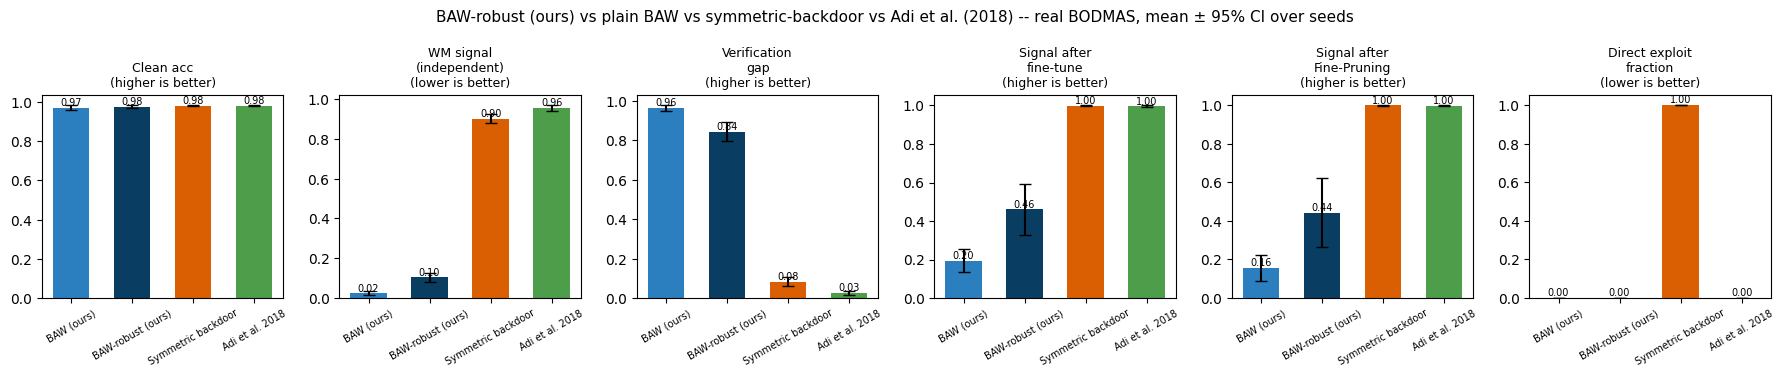

In [ ]:
fig_track_a_comparison(track_a_summary, track_a_comparisons)

### Bước 3 -- TRACK B.1: Ablation (K, PGD ε, watermark weight) trên BODMAS thật

~10-15 phút.

In [ ]:
ablations, track_b_data = run_track_b_ablations(X, y, timestamps, cfg)


TRACK B.1 -- ablations (K, PGD eps, watermark weight) on real BODMAS
[data] temporal split -> owner=15000  reference=10000  test(future)=6000  test starts at 2020-06-30
  base owner acc 0.9555  reference acc 0.9720
  sweep trigger_size (K)
    trigger_size=50
    trigger_size=100
    trigger_size=150
    trigger_size=300
  sweep pgd_eps
    pgd_eps=0.1
    pgd_eps=0.18
    pgd_eps=0.25
    pgd_eps=0.35
  sweep wm_trigger_weight
    wm_trigger_weight=0.5
    wm_trigger_weight=1.0
    wm_trigger_weight=2.0
    wm_trigger_weight=4.0


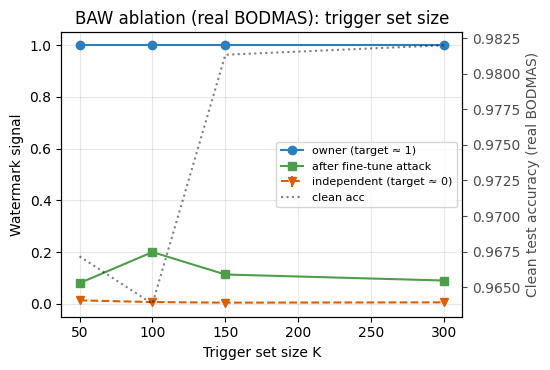

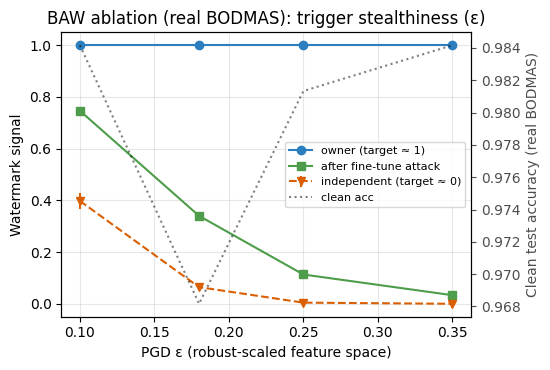

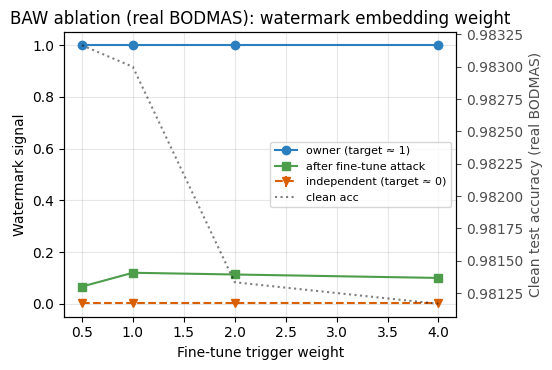

In [ ]:
fig_ablations(ablations)

### Bước 4 -- TRACK B.2: Chuyển giao sang detector KHÔNG differentiable (Gradient-Boosted Trees)

Detector thật ngoài đời thường là cây (LightGBM/XGBoost-style), không phải mạng nơ-ron. Mục này huấn luyện GBT thật, dùng surrogate MLP để craft/embed key, rồi kiểm tra key đó có thật sự hoạt động trên GBT thật không. ~2-3 phút.

In [ ]:
surrogate_result = run_track_b_surrogate(cfg, track_b_data)


TRACK B.2 -- non-differentiable detector transfer (GBT surrogate)
  owner GBT (non-differentiable) clean acc 0.9827  (55.6s)
  surrogate MLP trained (59.1s), agrees with GBT on 98.7% of test set
  BAW trigger set built (yield 100.0%)
  GBT watermark embedded via sample-weighted refit (60.6s)
  owner GBT clean acc: 0.9827 -> 0.9812
  owner GBT signal on trigger set: 1.0000  (target ~1.0)


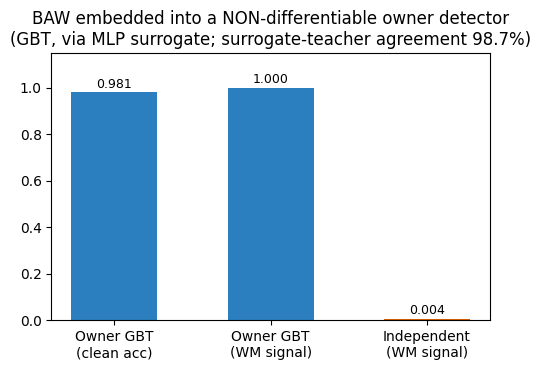

In [ ]:
fig_surrogate(surrogate_result)

### Bước 5 -- TRACK B.3: So sánh độ "lộ diện" (stealth / OOD-detectability) của 3 bộ trigger

Key mà attacker/leaker cầm có dễ bị flag là bất thường không? So sánh bằng Isolation Forest.

In [ ]:
stealth_result = run_track_b_stealth(cfg, track_b_data)


TRACK B.3 -- trigger-set stealth (OOD-detectability) comparison
  BAW (ours)              mean anomaly score +0.0371  outlier fraction 11.3%
  BAW-robust (ours)       mean anomaly score +0.0121  outlier fraction 30.7%
  Symmetric backdoor      mean anomaly score +0.0520  outlier fraction 1.3%
  Adi et al. 2018         mean anomaly score +0.0509  outlier fraction 0.0%


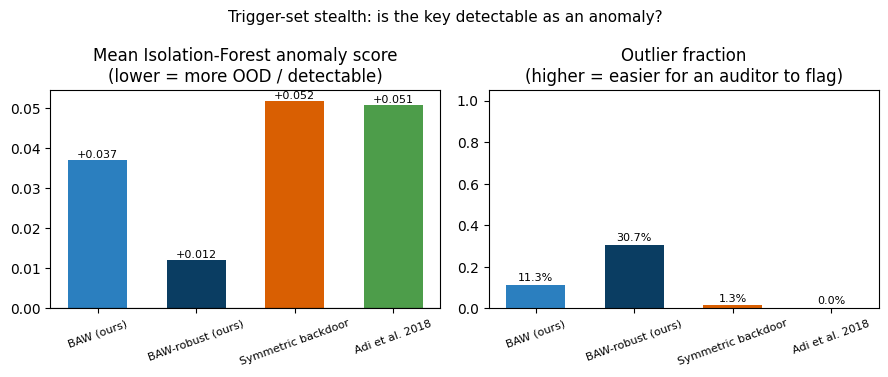

In [ ]:
fig_stealth(stealth_result)

### Bước 6 -- Lưu toàn bộ kết quả (JSON) và tải về

In [ ]:
import json, os

os.makedirs(cfg.outdir, exist_ok=True)
out = {
    "config": {k: v for k, v in cfg.__dict__.items()},
    "track_a_per_seed": per_seed_results,
    "track_a_summary": track_a_summary,
    "track_a_comparisons": track_a_comparisons,
    "track_b_ablations": ablations,
    "track_b_surrogate": surrogate_result,
    "track_b_stealth": stealth_result,
}
path = os.path.join(cfg.outdir, "results_real.json")
with open(path, "w") as f:
    json.dump(out, f, indent=2, default=str)
print(f"Đã lưu: {path}")

try:
    from google.colab import files
    files.download(path)
except ImportError:
    print("(Không chạy trong Colab -- file đã lưu tại đường dẫn trên.)")


Đã lưu: results_real/results_real.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>